# ***Estudio fenomenológico de la Forward-Backward asymmetry mediante técnicas de simulación numérica***

**Proceso:** $e^+e^- \to \mu^+\mu^-$  |  **método:** Monte Carlo (aceptación-rechazo) en Python

## ***Introducción***

El estudio de las corrientes neutras en el Modelo Estándar es clave para entender la interacción electrodébil. En colisiones de alta energía, una observable fundamental es la **Forward-Backward asymmetry** ($A_{FB}$), que surge de la **interferencia** entre el intercambio de un fotón virtual y el del bosón $Z$.

El cuaderno sigue el plan de trabajo completo:

1. análisis fenomenológico del proceso $e^+e^-\to\mu^+\mu^-$
2. derivar la sección eficaz diferencial a partir de la amplitud de dispersión
3. mantener los términos de interferencia $\gamma$–$Z$
4. implementar el algoritmo Monte Carlo (aceptación-rechazo) y analizar distintas energías $\sqrt{s}$, en particular $\sqrt{s}=m_Z=91.1876$ GeV, incorporando el propagador de Breit-Wigner
5. observar la distribución simétrica (solo fotón)
6. observar la transición de la distribución simétrica a la asimétrica
7. validar la sensibilidad del método para extraer parámetros físicos
8. **para cada ángulo de 0° a 180°: averiguar cuántas partículas entran en cada grado** (sección 10)

## ***1. Fenomenología del proceso***

A nivel árbol, el $e^+e^-$ se aniquila en un bosón virtual ($\gamma$ o $Z$) que después se convierte en un par $\mu^+\mu^-$. Se define

$$x=\cos\theta,$$

donde $\theta$ es el ángulo entre el $\mu^-$ saliente y el haz de $e^-$.

- **$x\to 1$** ($\theta\to0$): el muón sale hacia adelante (*forward*)
- **$x\to -1$** ($\theta\to\pi$): el muón sale hacia atrás (*backward*)

Con solo el fotón la distribución es simétrica. Con la $Z$ aparece un término lineal en $x$, y de ahí surge la Forward-Backward asymmetry.

## ***2. Sección eficaz a partir de la amplitud***

Se trabaja con fermiones sin masa ($m_e, m_\mu \ll \sqrt{s}$), de modo que la helicidad (*helicity*) se conserva en cada vértice. La amplitud total es la suma de la del fotón y la de la $Z$. Para un electrón de quiralidad $i$ y un muón de quiralidad $j$ ($i,j=L,R$):

$$\mathcal{M}_{ij}\;\propto\;\frac{e^2}{s}\Big[\,Q_eQ_\mu + g_i^{e}\,g_j^{\mu}\,\chi(s)\Big]\times(\text{helicity spinors})$$

donde el **propagador de Breit-Wigner** está contenido en

$$\chi(s)=\frac{1}{\sin^2\theta_W\cos^2\theta_W}\;\frac{s}{s-m_Z^2+i\,m_Z\Gamma_Z}$$

y los acoplamientos de la $Z$ a los leptones cargados son

$$g_L=T_3-Q\sin^2\theta_W,\qquad g_R=-Q\sin^2\theta_W,\qquad (Q=-1,\;T_3=-\tfrac12).$$

El factor de los *helicity spinors*, al elevarse al cuadrado, depende solo del ángulo:

$$|\text{helicity spinors}|^2\propto(1+x)^2\ \text{si } i=j\ (LL,RR),\qquad (1-x)^2\ \text{si } i\neq j\ (LR,RL).$$

Cuando las helicidades coinciden, la proyección del momento angular total sobre el eje del haz es $J_z=\pm1$ y el muón tiende a salir hacia adelante; para $i\neq j$ ocurre lo contrario.

Sumando sobre helicidades:

$$\frac{d\sigma}{dx}=\frac{\pi\alpha^2}{8s}\Big[S_{=}\,(1+x)^2+S_{\neq}\,(1-x)^2\Big],$$

con $S_{=}=|a_{LL}|^2+|a_{RR}|^2$, $S_{\neq}=|a_{LR}|^2+|a_{RL}|^2$ y $a_{ij}=Q_eQ_\mu+g_ig_j\chi(s)$.

Como $(1\pm x)^2=1+x^2\pm2x$, resulta

$$\boxed{\frac{d\sigma}{dx}=\frac{\pi\alpha^2}{2s}\Big[A\,(1+x^2)+B\,x\Big]}\qquad A=\frac{S_{=}+S_{\neq}}{4},\quad B=\frac{S_{=}-S_{\neq}}{2}.$$

Si solo existiera el fotón, $\chi=0$, de modo que $A=1$ y $B=0$, y se recupera la distribución simétrica $1+x^2$.

## ***3. Términos de interferencia $\gamma$–$Z$***

Al elevar al cuadrado $|a_{ij}|^2=|Q_eQ_\mu+g_ig_j\chi|^2$ aparecen tres tipos de términos:

$$|a_{ij}|^2=\underbrace{Q_e^2Q_\mu^2}_{\gamma\gamma}\;+\;\underbrace{2\,Q_eQ_\mu\,g_ig_j\,\mathrm{Re}\,\chi}_{\text{interferencia }\gamma Z}\;+\;\underbrace{(g_ig_j)^2|\chi|^2}_{ZZ}$$

- el término **$\gamma\gamma$** siempre está presente y es simétrico
- la **interferencia** es proporcional a $\mathrm{Re}\,\chi$, que cambia de signo al cruzar $m_Z$ (en el polo, $\mathrm{Re}\,\chi=0$)
- el término **$ZZ$** domina en la resonancia, por $|\chi|^2\propto 1/[(s-m_Z^2)^2+m_Z^2\Gamma_Z^2]$

De la forma $f(x)=A(1+x^2)+Bx$ se obtiene la Forward-Backward asymmetry:

$$A_{FB}=\frac{N_F-N_B}{N_F+N_B}=\frac{\int_0^1 f\,dx-\int_{-1}^0 f\,dx}{\int_{-1}^1 f\,dx}=\frac{3}{8}\frac{B}{A}.$$

## ***4. Implementación en Python***

### ***parámetros y coeficientes $A(\sqrt{s})$, $B(\sqrt{s})$***

Se definen las constantes y una función que calcula $A$ y $B$ para cualquier energía, con el propagador de Breit-Wigner incluido. Se usa $\sqrt{s}=m_Z$ exacto; no es necesario sumar ningún desplazamiento arbitrario a $s$, porque la función acepta cualquier energía.

$A$ también se separa en sus tres contribuciones ($\gamma\gamma$, interferencia y $ZZ$) para poder graficarlas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---- parámetros (GeV) ----
m_Z = 91.1876      # masa del bosón Z
Gamma_Z = 2.4952   # anchura de la resonancia
s2w = 0.23126      # sin^2(theta_W)

def propagador(raiz_s, s2w=s2w):
    '''chi(s): propagador de Breit-Wigner de la Z normalizado respecto al del fotón'''
    s = raiz_s**2
    return s / (s - m_Z**2 + 1j * m_Z * Gamma_Z) / (s2w * (1 - s2w))

def coeficientes(raiz_s, s2w=s2w):
    '''A y B de f(x) = A(1+x^2) + B x para e+e- -> mu+mu- a energía raiz_s (GeV)'''
    Q, T3 = -1.0, -0.5                     # carga y isospín de e y mu
    gL = T3 - Q * s2w                      # acoplamiento quiral izquierdo
    gR = -Q * s2w                          # acoplamiento quiral derecho
    chi = propagador(raiz_s, s2w)

    a = lambda gi, gj: Q * Q + gi * gj * chi       # amplitud gamma + Z
    S_igual = abs(a(gL, gL))**2 + abs(a(gR, gR))**2   # LL + RR
    S_dif   = abs(a(gL, gR))**2 + abs(a(gR, gL))**2   # LR + RL

    A = (S_igual + S_dif) / 4
    B = (S_igual - S_dif) / 2
    return A, B

def terminos_A(raiz_s, s2w=s2w):
    '''A = gamma-gamma + interferencia + ZZ'''
    Q, T3 = -1.0, -0.5
    gL, gR = T3 - Q * s2w, -Q * s2w
    chi = propagador(raiz_s, s2w)
    A_gg = Q**4
    A_int = Q**2 * chi.real * (gL + gR)**2 / 2
    A_zz = (gL**2 + gR**2)**2 * abs(chi)**2 / 4
    return A_gg, A_int, A_zz

def f(x, A, B):
    return A * (1 + x**2) + B * x

def afb_teorica(raiz_s, s2w=s2w):
    A, B = coeficientes(raiz_s, s2w)
    return 3 * B / (8 * A)

# chequeo: las tres contribuciones deben sumar A
assert abs(sum(terminos_A(95.0)) - coeficientes(95.0)[0]) < 1e-9

A_Z, B_Z = coeficientes(m_Z)
print(f"en el polo de la Z (raiz_s = {m_Z} GeV):")
print(f"A = {A_Z:.4f}")
print(f"B = {B_Z:.4f}")
print(f"A_FB teórica = {afb_teorica(m_Z):.4f}")

en el polo de la Z (raiz_s = 91.1876 GeV):
A = 167.9275
B = 7.4201
A_FB teórica = 0.0166


Verificación: en el polo, la $A_{FB}$ debe resultar pequeña y positiva ($\approx 0.017$), porque $g_V=T_3-2Q\sin^2\theta_W\approx -0.04$ es casi cero para leptones y $A_{FB}\propto g_V^2$.

### ***comportamiento de $A$, $B$ y sus contribuciones con la energía***

Se presentan tres gráficas: los coeficientes $A_{NC}$ y $|B_{NC}|$ en escala log, la Forward-Backward asymmetry teórica y el peso relativo de cada contribución a $A_{NC}$.

/usr/local/lib/python3.12/site-packages/pydantic/main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `LineChart` - serialized value may not be as expected [input_value=Chart(type=<ChartType.UNK... $A_{NC}$', elements=[]), input_type=Chart])
  PydanticSerializationUnexpectedValue(Expected `ScatterChart` - serialized value may not be as expected [input_value=Chart(type=<ChartType.UNK... $A_{NC}$', elements=[]), input_type=Chart])
  PydanticSerializationUnexpectedValue(Expected `BarChart` - serialized value may not be as expected [input_value=Chart(type=<ChartType.UNK... $A_{NC}$', elements=[]), input_type=Chart])
  PydanticSerializationUnexpectedValue(Expected `PieChart` - serialized value may not be as expected [input_value=Chart(type=<ChartType.UNK... $A_{NC}$', elements=[]), input_type=Chart])
  PydanticSerializationUnexpectedValue(Expected `BoxAndWhiskerChart` - serialized value may not be as expected [input_value=Chart(type=<ChartT

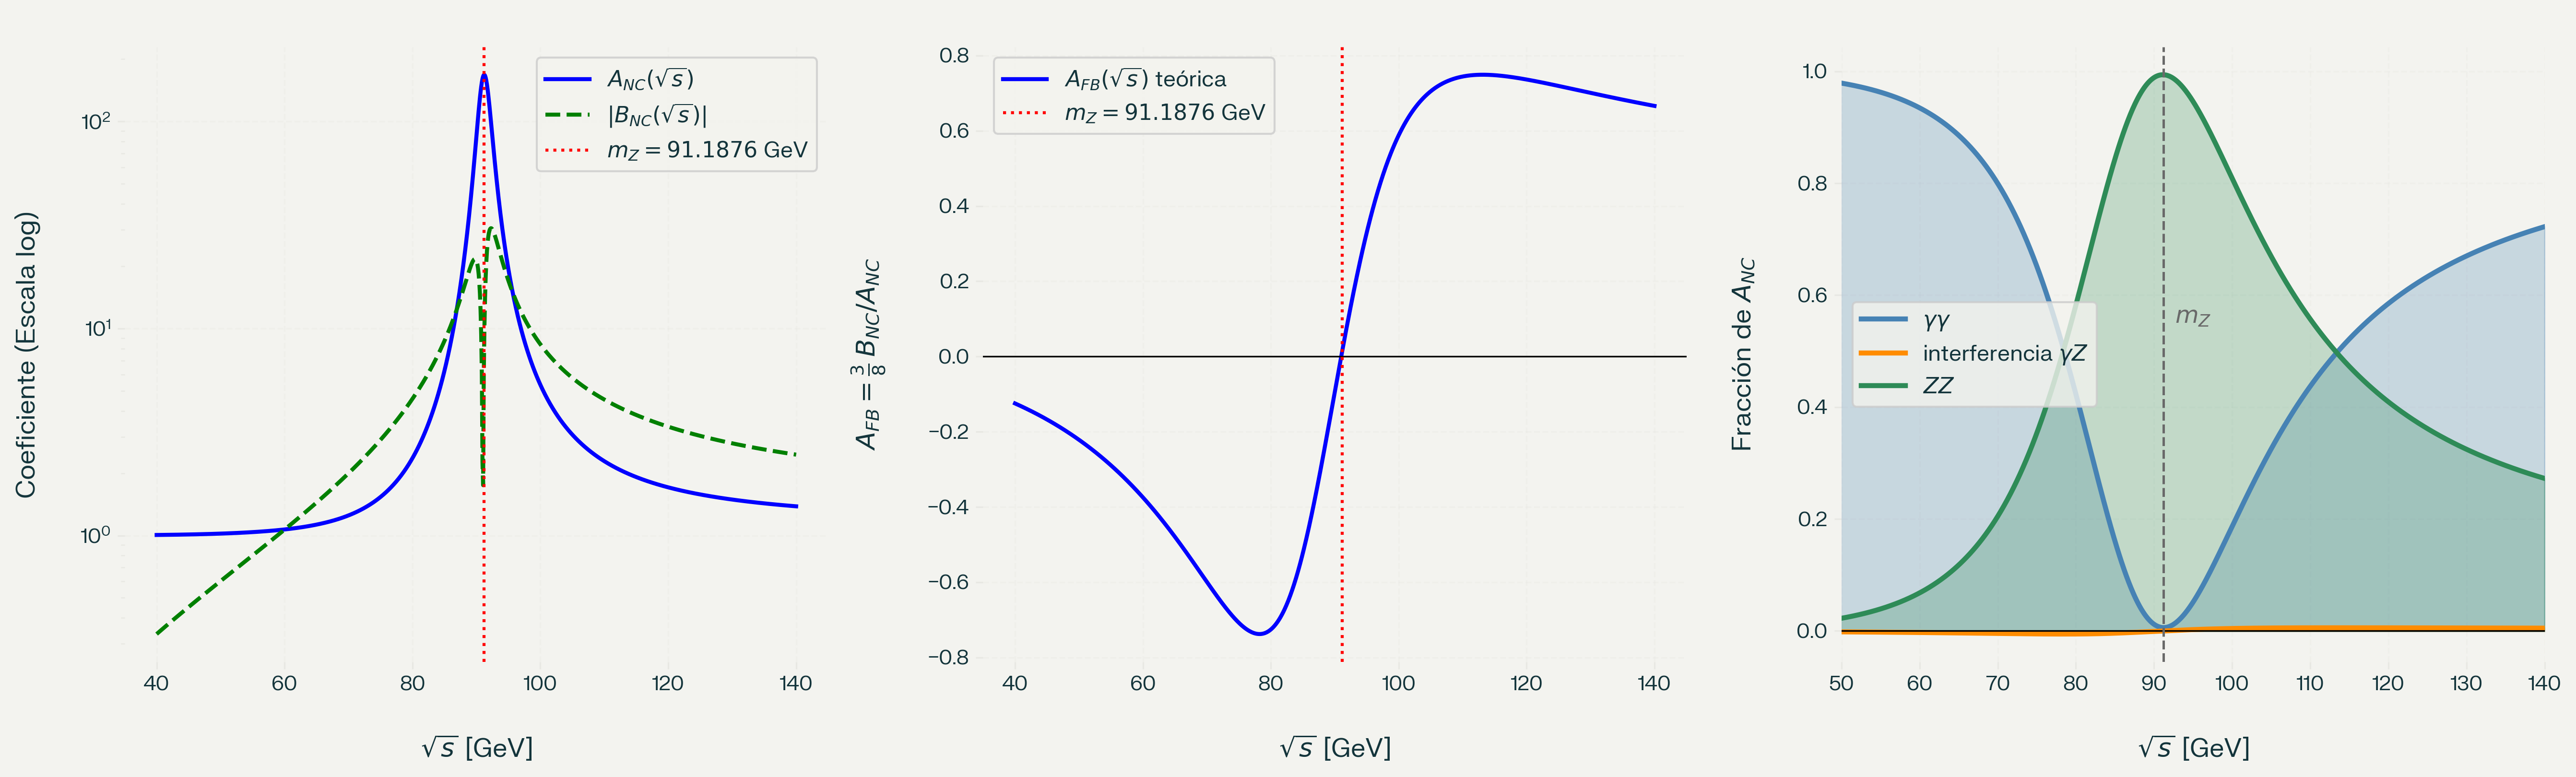

In [2]:
ECM_vals = np.linspace(40, 140, 1000)
A_arr = np.array([coeficientes(E)[0] for E in ECM_vals])
B_arr = np.array([coeficientes(E)[1] for E in ECM_vals])
afb_E = 3 * B_arr / (8 * A_arr)
T = np.array([terminos_A(E) for E in ECM_vals])      # columnas: gg, int, zz

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

ax = axes[0]
ax.plot(ECM_vals, A_arr, 'b-', linewidth=2, label=r'$A_{NC}(\sqrt{s})$')
ax.plot(ECM_vals, np.abs(B_arr), 'g--', linewidth=2, label=r'$|B_{NC}(\sqrt{s})|$')
ax.axvline(m_Z, color='red', linestyle=':', linewidth=1.5, label=f'$m_Z = {m_Z}$ GeV')
ax.set_yscale('log')
ax.set_xlabel(r'$\sqrt{s}$ [GeV]', fontsize=13)
ax.set_ylabel('Coeficiente (Escala log)', fontsize=13)
ax.set_title('Coeficientes $A_{NC}$ y $|B_{NC}|$ vs Energía', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

ax = axes[1]
ax.plot(ECM_vals, afb_E, 'b-', linewidth=2, label=r'$A_{FB}(\sqrt{s})$ teórica')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(m_Z, color='red', linestyle=':', linewidth=1.5, label=f'$m_Z = {m_Z}$ GeV')
ax.set_xlabel(r'$\sqrt{s}$ [GeV]', fontsize=13)
ax.set_ylabel(r'$A_{FB} = \frac{3}{8}\,B_{NC}/A_{NC}$', fontsize=13)
ax.set_title('Forward-Backward asymmetry vs Energía', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

# contribución relativa de cada término a A_NC (las tres fracciones suman 1)
ax = axes[2]
frac = T / A_arr[:, None]
colores = ['steelblue', 'darkorange', 'seagreen']
etiquetas = [r'$\gamma\gamma$', r'interferencia $\gamma Z$', r'$ZZ$']
for j in range(3):
    ax.fill_between(ECM_vals, frac[:, j], 0, color=colores[j], alpha=0.25)
    ax.plot(ECM_vals, frac[:, j], color=colores[j], linewidth=2.5, label=etiquetas[j])
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(m_Z, color='dimgray', linestyle='--', linewidth=1.2)
ax.text(m_Z + 1.5, 0.55, r'$m_Z$', color='dimgray', fontsize=12)
ax.set_xlim(50, 140)
ax.set_xlabel(r'$\sqrt{s}$ [GeV]', fontsize=13)
ax.set_ylabel(r'Fracción de $A_{NC}$', fontsize=13)
ax.set_title('Peso relativo de cada contribución a $A_{NC}$', fontsize=13)
ax.legend(fontsize=11, loc='center left')
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

Observaciones:

- $A_{NC}$ presenta el pico en $m_Z$ (casi 170 veces el valor del fotón solo), mientras que $|B_{NC}|$ en el polo es mucho menor; la razón $B_{NC}/A_{NC}$ es pequeña y por eso la asimetría es chica
- la Forward-Backward asymmetry es negativa debajo de la resonancia, pasa por casi cero en el polo y crece rápido hacia valores positivos grandes arriba de ella
- en la tercera gráfica el término $\gamma\gamma$ domina lejos de la resonancia, el término $ZZ$ domina en torno a $m_Z$, y la interferencia es negativa por debajo del polo, positiva por encima y se anula en $m_Z$

### ***algoritmo de aceptación-rechazo***

El método genera eventos que siguen $f(x)$ de la siguiente forma:

1. proponer un valor aleatorio $x\in[-1,1]$
2. proponer una altura aleatoria $y\in[0,f_{\max}]$
3. si $y\le f(x)$, aceptar el evento
4. si $y>f(x)$, rechazar y repetir

La eficiencia es $\eta=\dfrac{\text{área bajo }f(x)}{\text{área del rectángulo}}$.

El algoritmo se encapsula en una función para reutilizarlo en cada caso. Es la misma lógica del ciclo `while` por evento, pero propone 20 000 puntos por iteración, de modo que escala a millones de eventos.

In [3]:
def rejection_sampling(A, B, n_events, x_min=-1, x_max=1):
    '''genera n_events valores de x = cos(theta) con distribución f(x) = A(1+x^2) + Bx'''
    x_test = np.linspace(x_min, x_max, 1000)
    f_max = np.max(f(x_test, A, B)) * 1.05           # techo del rectángulo
    if np.min(f(x_test, A, B)) < 0:
        raise ValueError("f(x) es negativa: con esos A y B no es una probabilidad")

    aceptados = np.array([])
    n_attempts = 0
    while len(aceptados) < n_events:
        x_proposal = np.random.uniform(x_min, x_max, 20000)
        y_proposal = np.random.uniform(0, f_max, 20000)
        aceptados = np.concatenate([aceptados, x_proposal[y_proposal <= f(x_proposal, A, B)]])
        n_attempts += 20000

    eventos = aceptados[:n_events]
    eficiencia = n_events / n_attempts * 100
    return eventos, eficiencia

def asimetria_fb(x):
    '''A_FB medida: (N_forward - N_backward) / N_total'''
    return (np.sum(x > 0) - np.sum(x < 0)) / len(x)

def error_afb(afb, N):
    return np.sqrt((1 - afb**2) / N)

def grafica_eventos(ax, eventos, A, B, etiqueta_teoria, titulo, bins=100):
    '''histograma dorado + curva teórica roja'''
    ax.hist(eventos, bins=bins, density=True, alpha=0.7, color='goldenrod',
            edgecolor='black', linewidth=0.5, label='eventos simulados (mc)')
    x_theory = np.linspace(-1, 1, 1000)
    y_theory = f(x_theory, A, B)
    normalization = np.trapz(y_theory, x_theory)
    ax.plot(x_theory, y_theory / normalization, 'r-', linewidth=2.5, label=etiqueta_teoria)
    ax.set_xlabel(r'$x = \cos(\theta)$', fontsize=13)
    ax.set_ylabel('densidad de probabilidad', fontsize=13)
    ax.set_title(titulo, fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')

def chi2_y_pulls(eventos, A, B, n_bins=30):
    '''chi2 y residuos normalizados (obs - esp)/sqrt(esp) bin por bin'''
    observed, bin_edges = np.histogram(eventos, bins=n_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]
    x_theory = np.linspace(-1, 1, 1000)
    normalization = np.trapz(f(x_theory, A, B), x_theory)
    expected = f(bin_centers, A, B) / normalization * len(eventos) * bin_width
    pulls = (observed - expected) / np.sqrt(expected)
    return np.sum(pulls**2), n_bins - 1, bin_centers, pulls

def figura_caso(eventos, A, B, etiqueta_teoria, titulo):
    '''dos paneles: histograma vs teoría, y residuos bin por bin'''
    chi2, ndof, centros, pulls = chi2_y_pulls(eventos, A, B)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    grafica_eventos(axes[0], eventos, A, B, etiqueta_teoria, titulo)

    ax = axes[1]
    ax.plot(centros, pulls, 'b-o', linewidth=2, markersize=4, label='residuos normalizados')
    ax.axhline(0, color='red', linestyle=':', linewidth=1.5, label='ajuste perfecto')
    ax.axhline(2, color='green', linestyle='--', linewidth=1.5, label=r'$\pm 2\sigma$')
    ax.axhline(-2, color='green', linestyle='--', linewidth=1.5)
    ax.set_ylim(-4, 4)
    ax.set_xlabel(r'$x = \cos(\theta)$', fontsize=13)
    ax.set_ylabel(r'$(O_i - E_i)/\sqrt{E_i}$', fontsize=13)
    ax.set_title(rf'Residuos: $\chi^2/ndof = {chi2/ndof:.2f}$', fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

def resumen(eventos, eficiencia, A, B):
    afb = asimetria_fb(eventos)
    chi2, ndof, _, _ = chi2_y_pulls(eventos, A, B)
    print(f"eventos generados: {len(eventos)}")
    print(f"eficiencia: {eficiencia:.2f}%")
    print(f"media de x: {np.mean(eventos):.5f}")
    print(f"desviación estándar: {np.std(eventos):.5f}")
    print(f"A_FB simulada = {afb:+.4f} +- {error_afb(afb, len(eventos)):.4f}   |   teórica = {3*B/(8*A):+.4f}")
    print(f"chi2/ndof = {chi2:.1f}/{ndof} = {chi2/ndof:.3f}   (cerca de 1 --> buen ajuste)")

n_events = 10000
np.random.seed(42)

## ***5. Caso 1: distribución simétrica (solo fotón)***

**modelo:** $f(x)=1+x^2$, es decir $A=1$ y $B=0$.

Corresponde a lo que se obtendría si no existiera la $Z$. Se espera:

- media de $x$ cercana a 0 (por simetría)
- distribución tipo **"U"** (más eventos en $\theta\approx0$ y $\theta\approx\pi$, y menos a $90^\circ$)
- $A_{FB}\approx0$

La gráfica de la derecha muestra los residuos: si la simulación sigue a la teoría, casi todos los puntos deben quedar entre las líneas verdes ($\pm2\sigma$).

eventos generados: 10000
eficiencia: 50.00%
media de x: -0.00583
desviación estándar: 0.63269
A_FB simulada = -0.0114 +- 0.0100   |   teórica = +0.0000
chi2/ndof = 27.9/29 = 0.961   (cerca de 1 --> buen ajuste)


/usr/local/lib/python3.12/site-packages/pydantic/main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `LineChart` - serialized value may not be as expected [input_value=Chart(type=<ChartType.UNK...0 eventos', elements=[]), input_type=Chart])
  PydanticSerializationUnexpectedValue(Expected `ScatterChart` - serialized value may not be as expected [input_value=Chart(type=<ChartType.UNK...0 eventos', elements=[]), input_type=Chart])
  PydanticSerializationUnexpectedValue(Expected `BarChart` - serialized value may not be as expected [input_value=Chart(type=<ChartType.UNK...0 eventos', elements=[]), input_type=Chart])
  PydanticSerializationUnexpectedValue(Expected `PieChart` - serialized value may not be as expected [input_value=Chart(type=<ChartType.UNK...0 eventos', elements=[]), input_type=Chart])
  PydanticSerializationUnexpectedValue(Expected `BoxAndWhiskerChart` - serialized value may not be as expected [input_value=Chart(type=<ChartT

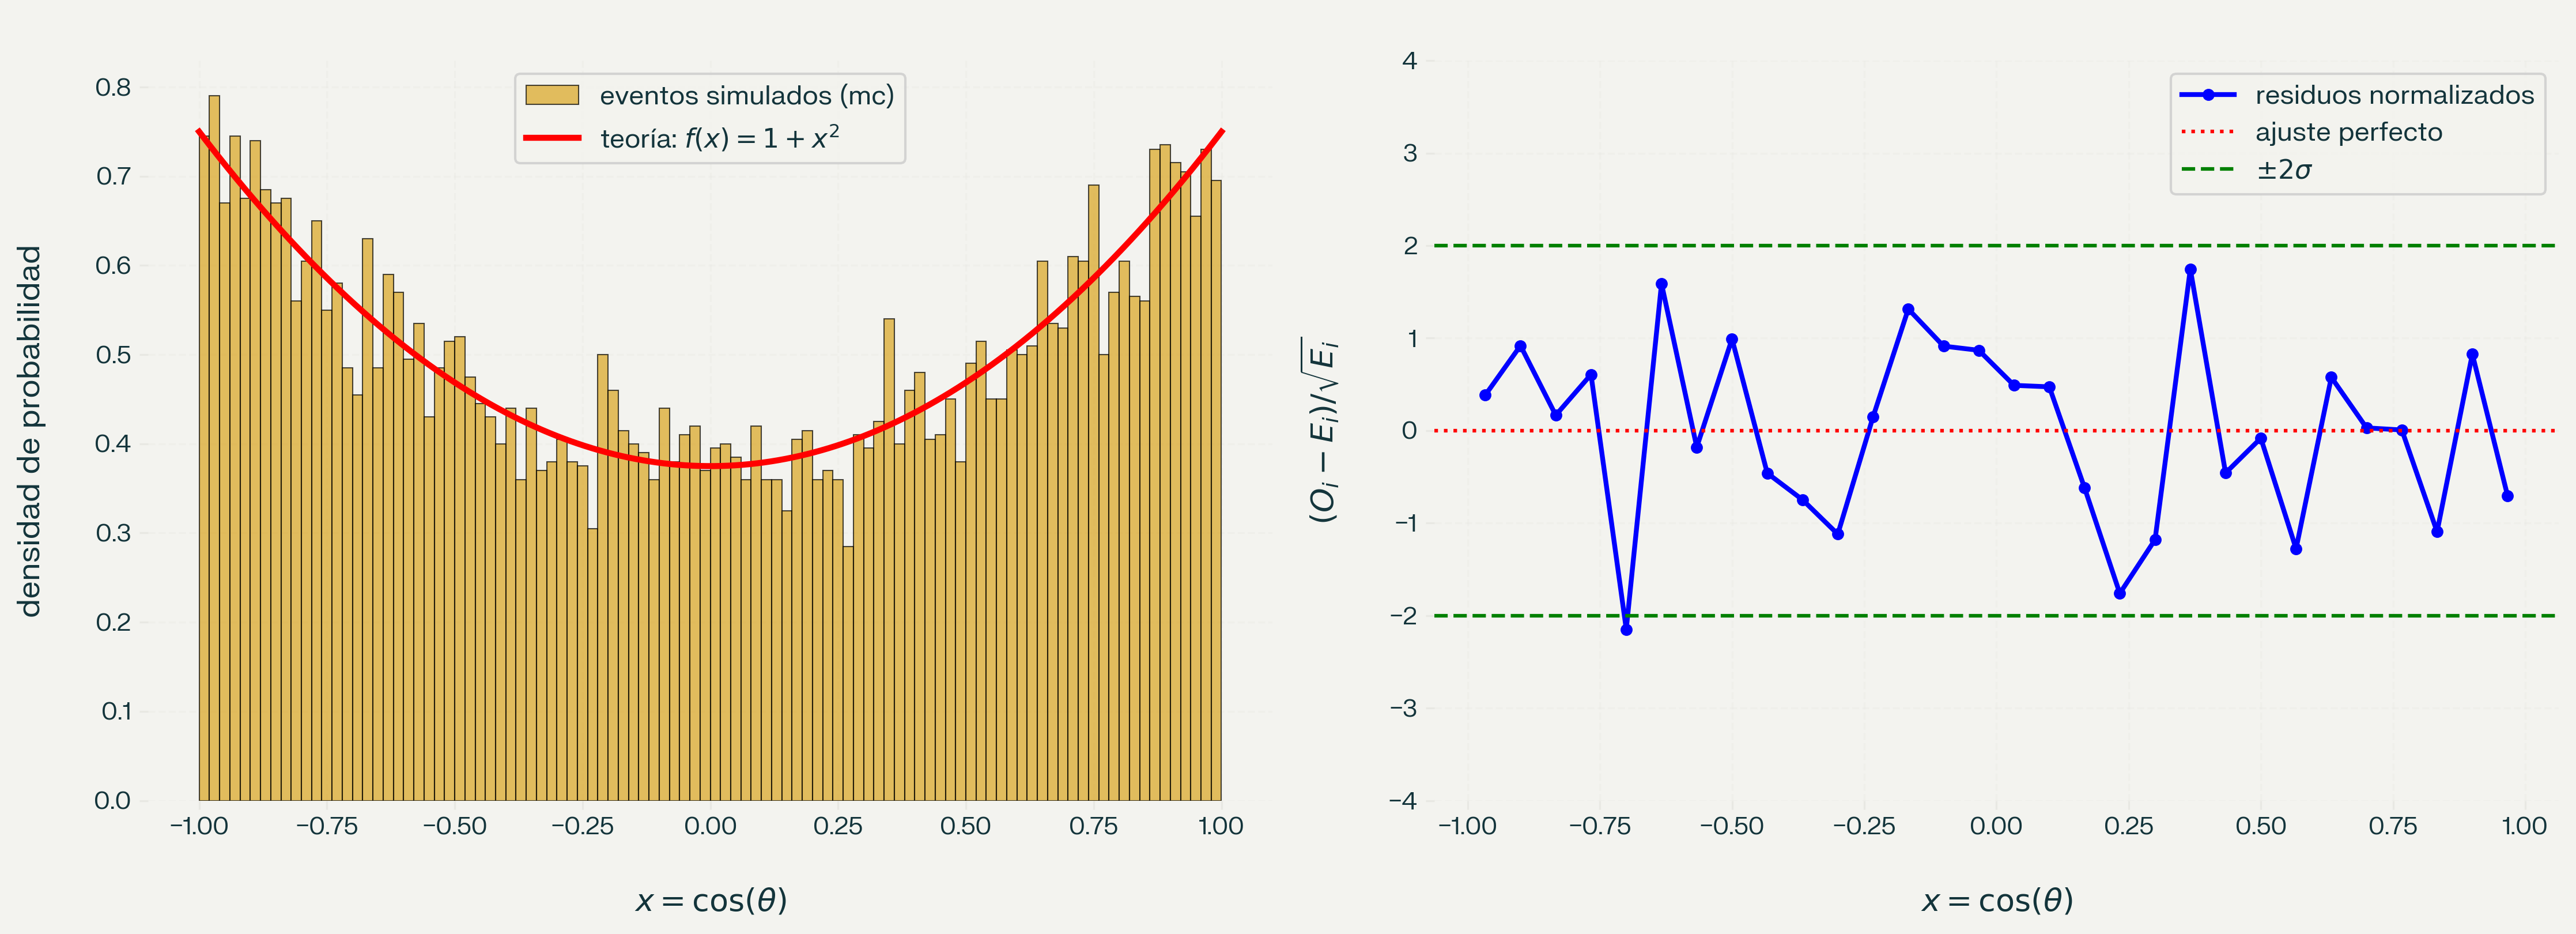

In [4]:
A_sim, B_sim = 1.0, 0.0
ev_sim, ef_sim = rejection_sampling(A_sim, B_sim, n_events)
resumen(ev_sim, ef_sim, A_sim, B_sim)

figura_caso(ev_sim, A_sim, B_sim, r'teoría: $f(x) = 1 + x^2$',
            f'Distribución simétrica (solo fotón): {n_events} eventos')

## ***6. Caso 2: asimetría propuesta***

Antes de usar el Modelo Estándar conviene aislar el efecto del término lineal. Se proponen valores *ideales*:

$$A_{ideal}=1,\qquad B_{ideal}=0.5\qquad\Rightarrow\qquad A_{FB}=\tfrac{3}{8}(0.5)=0.1875$$

No es un cálculo físico sino una suposición para visualizar el efecto: la curva se inclina hacia $x>0$ (más eventos *forward*).

eventos generados: 10000
eficiencia: 50.00%
media de x: 0.12583
desviación estándar: 0.62004
A_FB simulada = +0.1948 +- 0.0098   |   teórica = +0.1875
chi2/ndof = 23.7/29 = 0.818   (cerca de 1 --> buen ajuste)


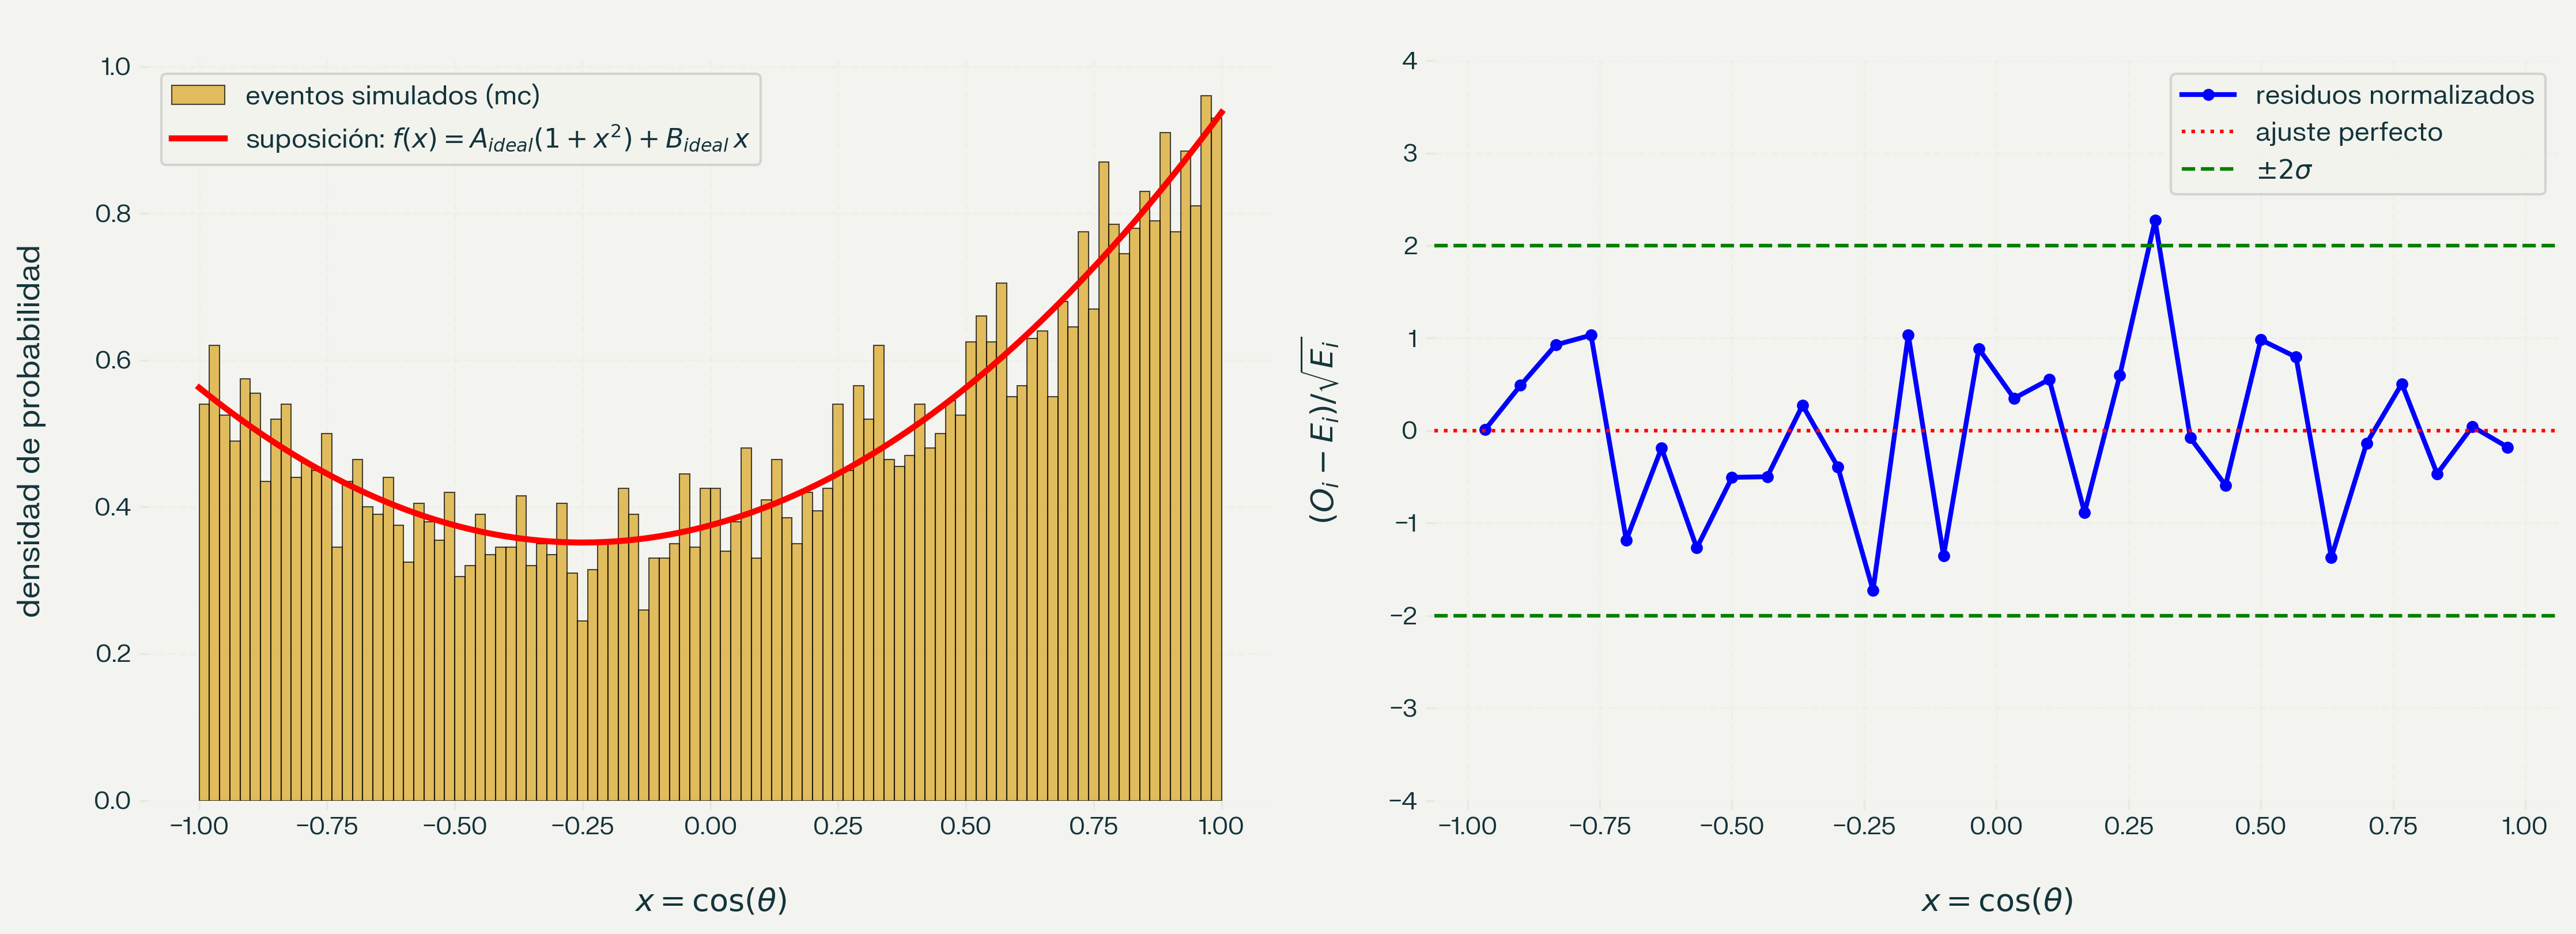

In [5]:
A_ideal, B_ideal = 1.0, 0.5
ev_ideal, ef_ideal = rejection_sampling(A_ideal, B_ideal, n_events)
resumen(ev_ideal, ef_ideal, A_ideal, B_ideal)

figura_caso(ev_ideal, A_ideal, B_ideal,
            r'suposición: $f(x) = A_{ideal}(1 + x^2) + B_{ideal}\,x$',
            f'Asimetría propuesta: {n_events} eventos')

## ***7. Caso 3: corrientes neutras en el polo de la $Z$***

Se usan $A_{NC}$ y $B_{NC}$ de la función `coeficientes` a $\sqrt{s}=m_Z$. Como $A_{NC}\approx168$ y $B_{NC}\approx7.4$, la razón $B/A$ es pequeña: la distribución es casi simétrica y la asimetría es sutil ($A_{FB}\approx0.017$).

A_NC = 167.9275   B_NC = 7.4201
eventos generados: 10000
eficiencia: 50.00%
media de x: 0.00475
desviación estándar: 0.63563
A_FB simulada = +0.0110 +- 0.0100   |   teórica = +0.0166
chi2/ndof = 32.1/29 = 1.107   (cerca de 1 --> buen ajuste)


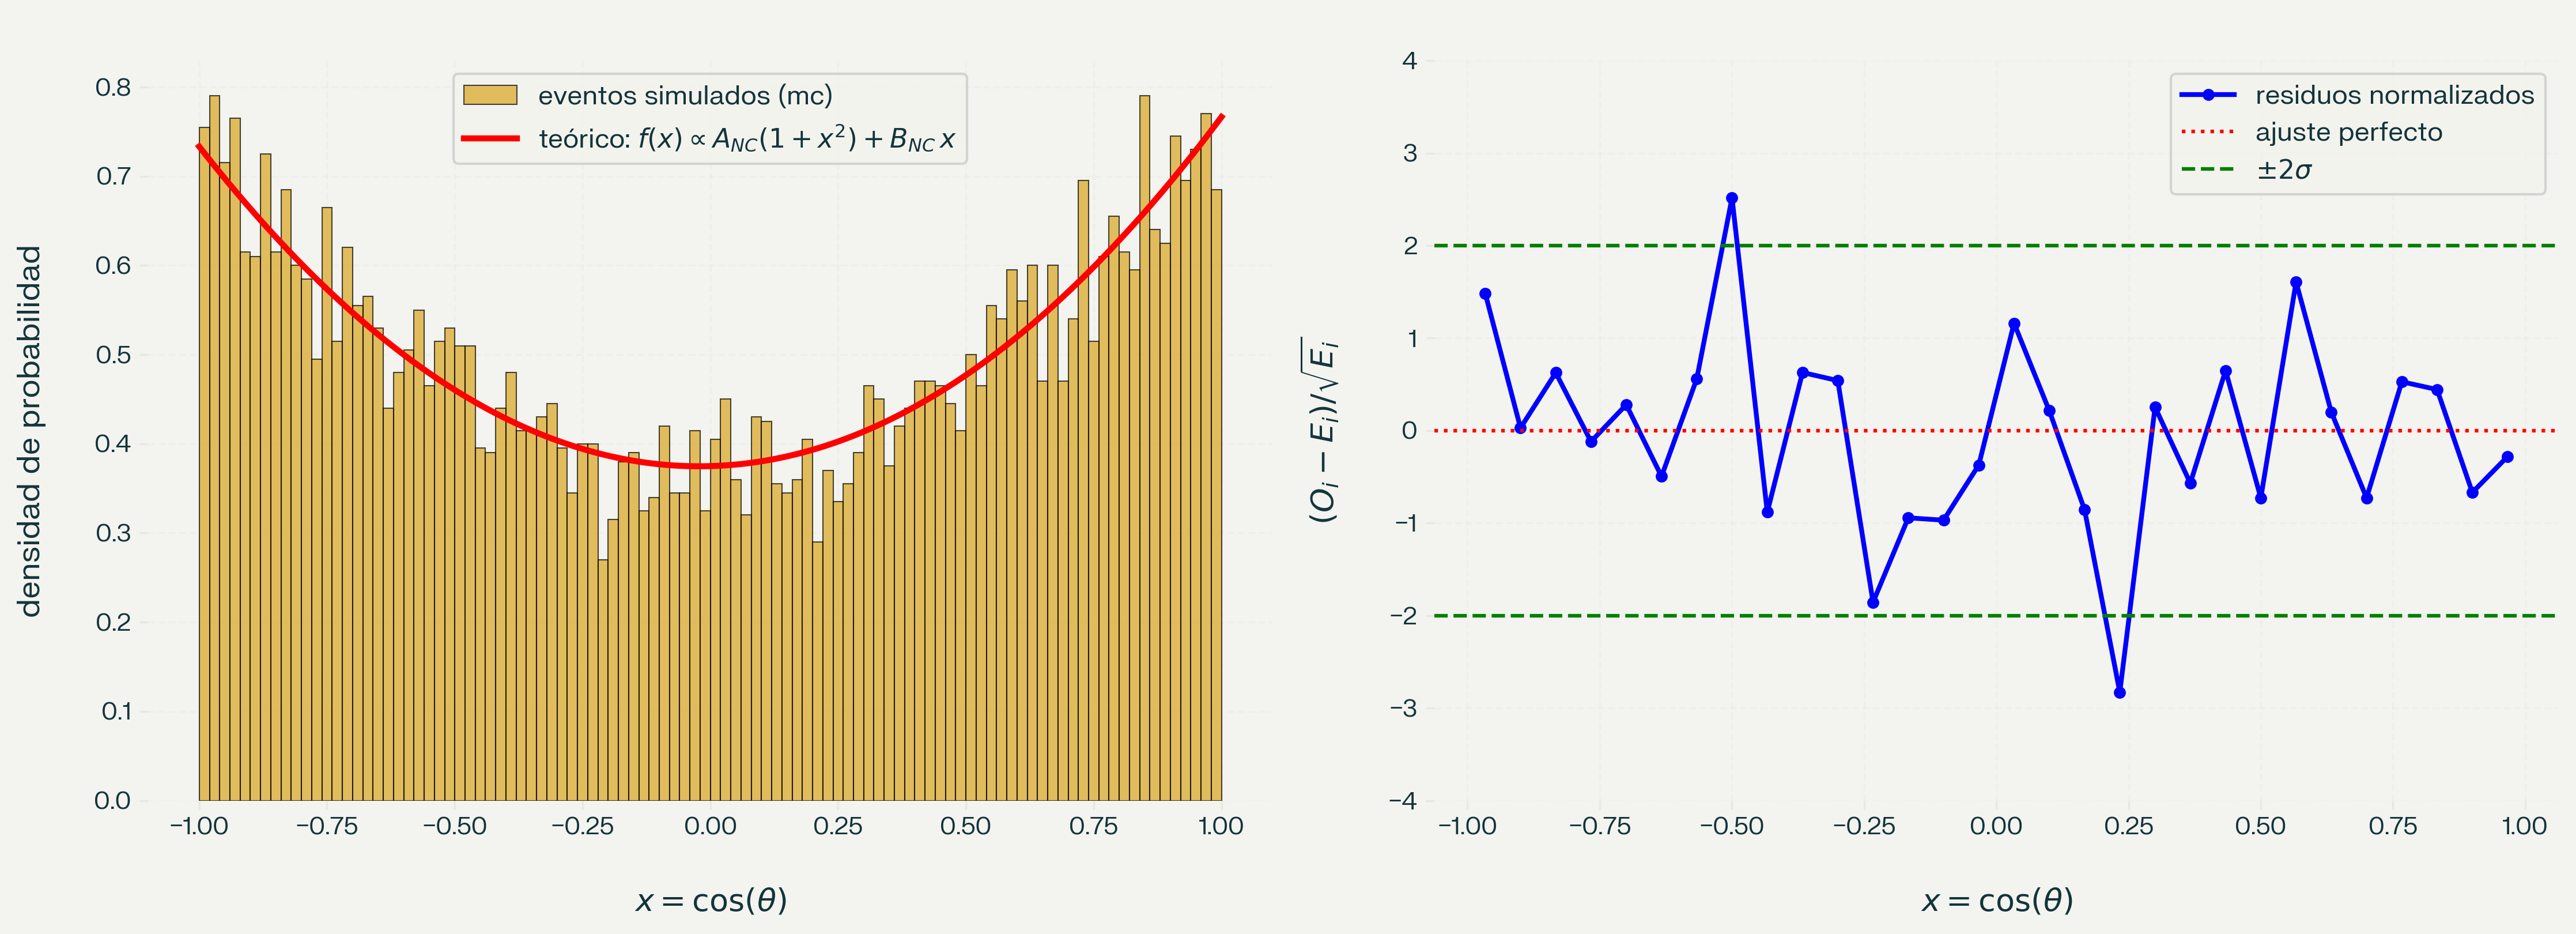

In [6]:
A_NC, B_NC = coeficientes(m_Z)
ev_nc, ef_nc = rejection_sampling(A_NC, B_NC, n_events)
print(f"A_NC = {A_NC:.4f}   B_NC = {B_NC:.4f}")
resumen(ev_nc, ef_nc, A_NC, B_NC)

figura_caso(ev_nc, A_NC, B_NC,
            r'teórico: $f(x) \propto A_{NC}(1 + x^2) + B_{NC}\,x$',
            f'Corrientes neutras, $\\sqrt{{s}}=m_Z$: {n_events} eventos')

Con 10 000 eventos el error estadístico de $A_{FB}$ es $\approx 1/\sqrt{N}=0.01$, comparable a la señal ($0.017$). Por ello la $A_{FB}$ simulada puede diferir de la teórica sin que exista ningún error en el código. Este efecto se estudia en el punto 7 del plan.

## ***8. Transición simétrica → asimétrica***

Se generan 10 000 eventos a varias energías, desde muy por debajo de la resonancia hasta muy por encima.

/usr/local/lib/python3.12/site-packages/pydantic/main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `LineChart` - serialized value may not be as expected [input_value=Chart(type=<ChartType.UNK...}$=-0.076', elements=[]), input_type=Chart])
  PydanticSerializationUnexpectedValue(Expected `ScatterChart` - serialized value may not be as expected [input_value=Chart(type=<ChartType.UNK...}$=-0.076', elements=[]), input_type=Chart])
  PydanticSerializationUnexpectedValue(Expected `BarChart` - serialized value may not be as expected [input_value=Chart(type=<ChartType.UNK...}$=-0.076', elements=[]), input_type=Chart])
  PydanticSerializationUnexpectedValue(Expected `PieChart` - serialized value may not be as expected [input_value=Chart(type=<ChartType.UNK...}$=-0.076', elements=[]), input_type=Chart])
  PydanticSerializationUnexpectedValue(Expected `BoxAndWhiskerChart` - serialized value may not be as expected [input_value=Chart(type=<ChartT

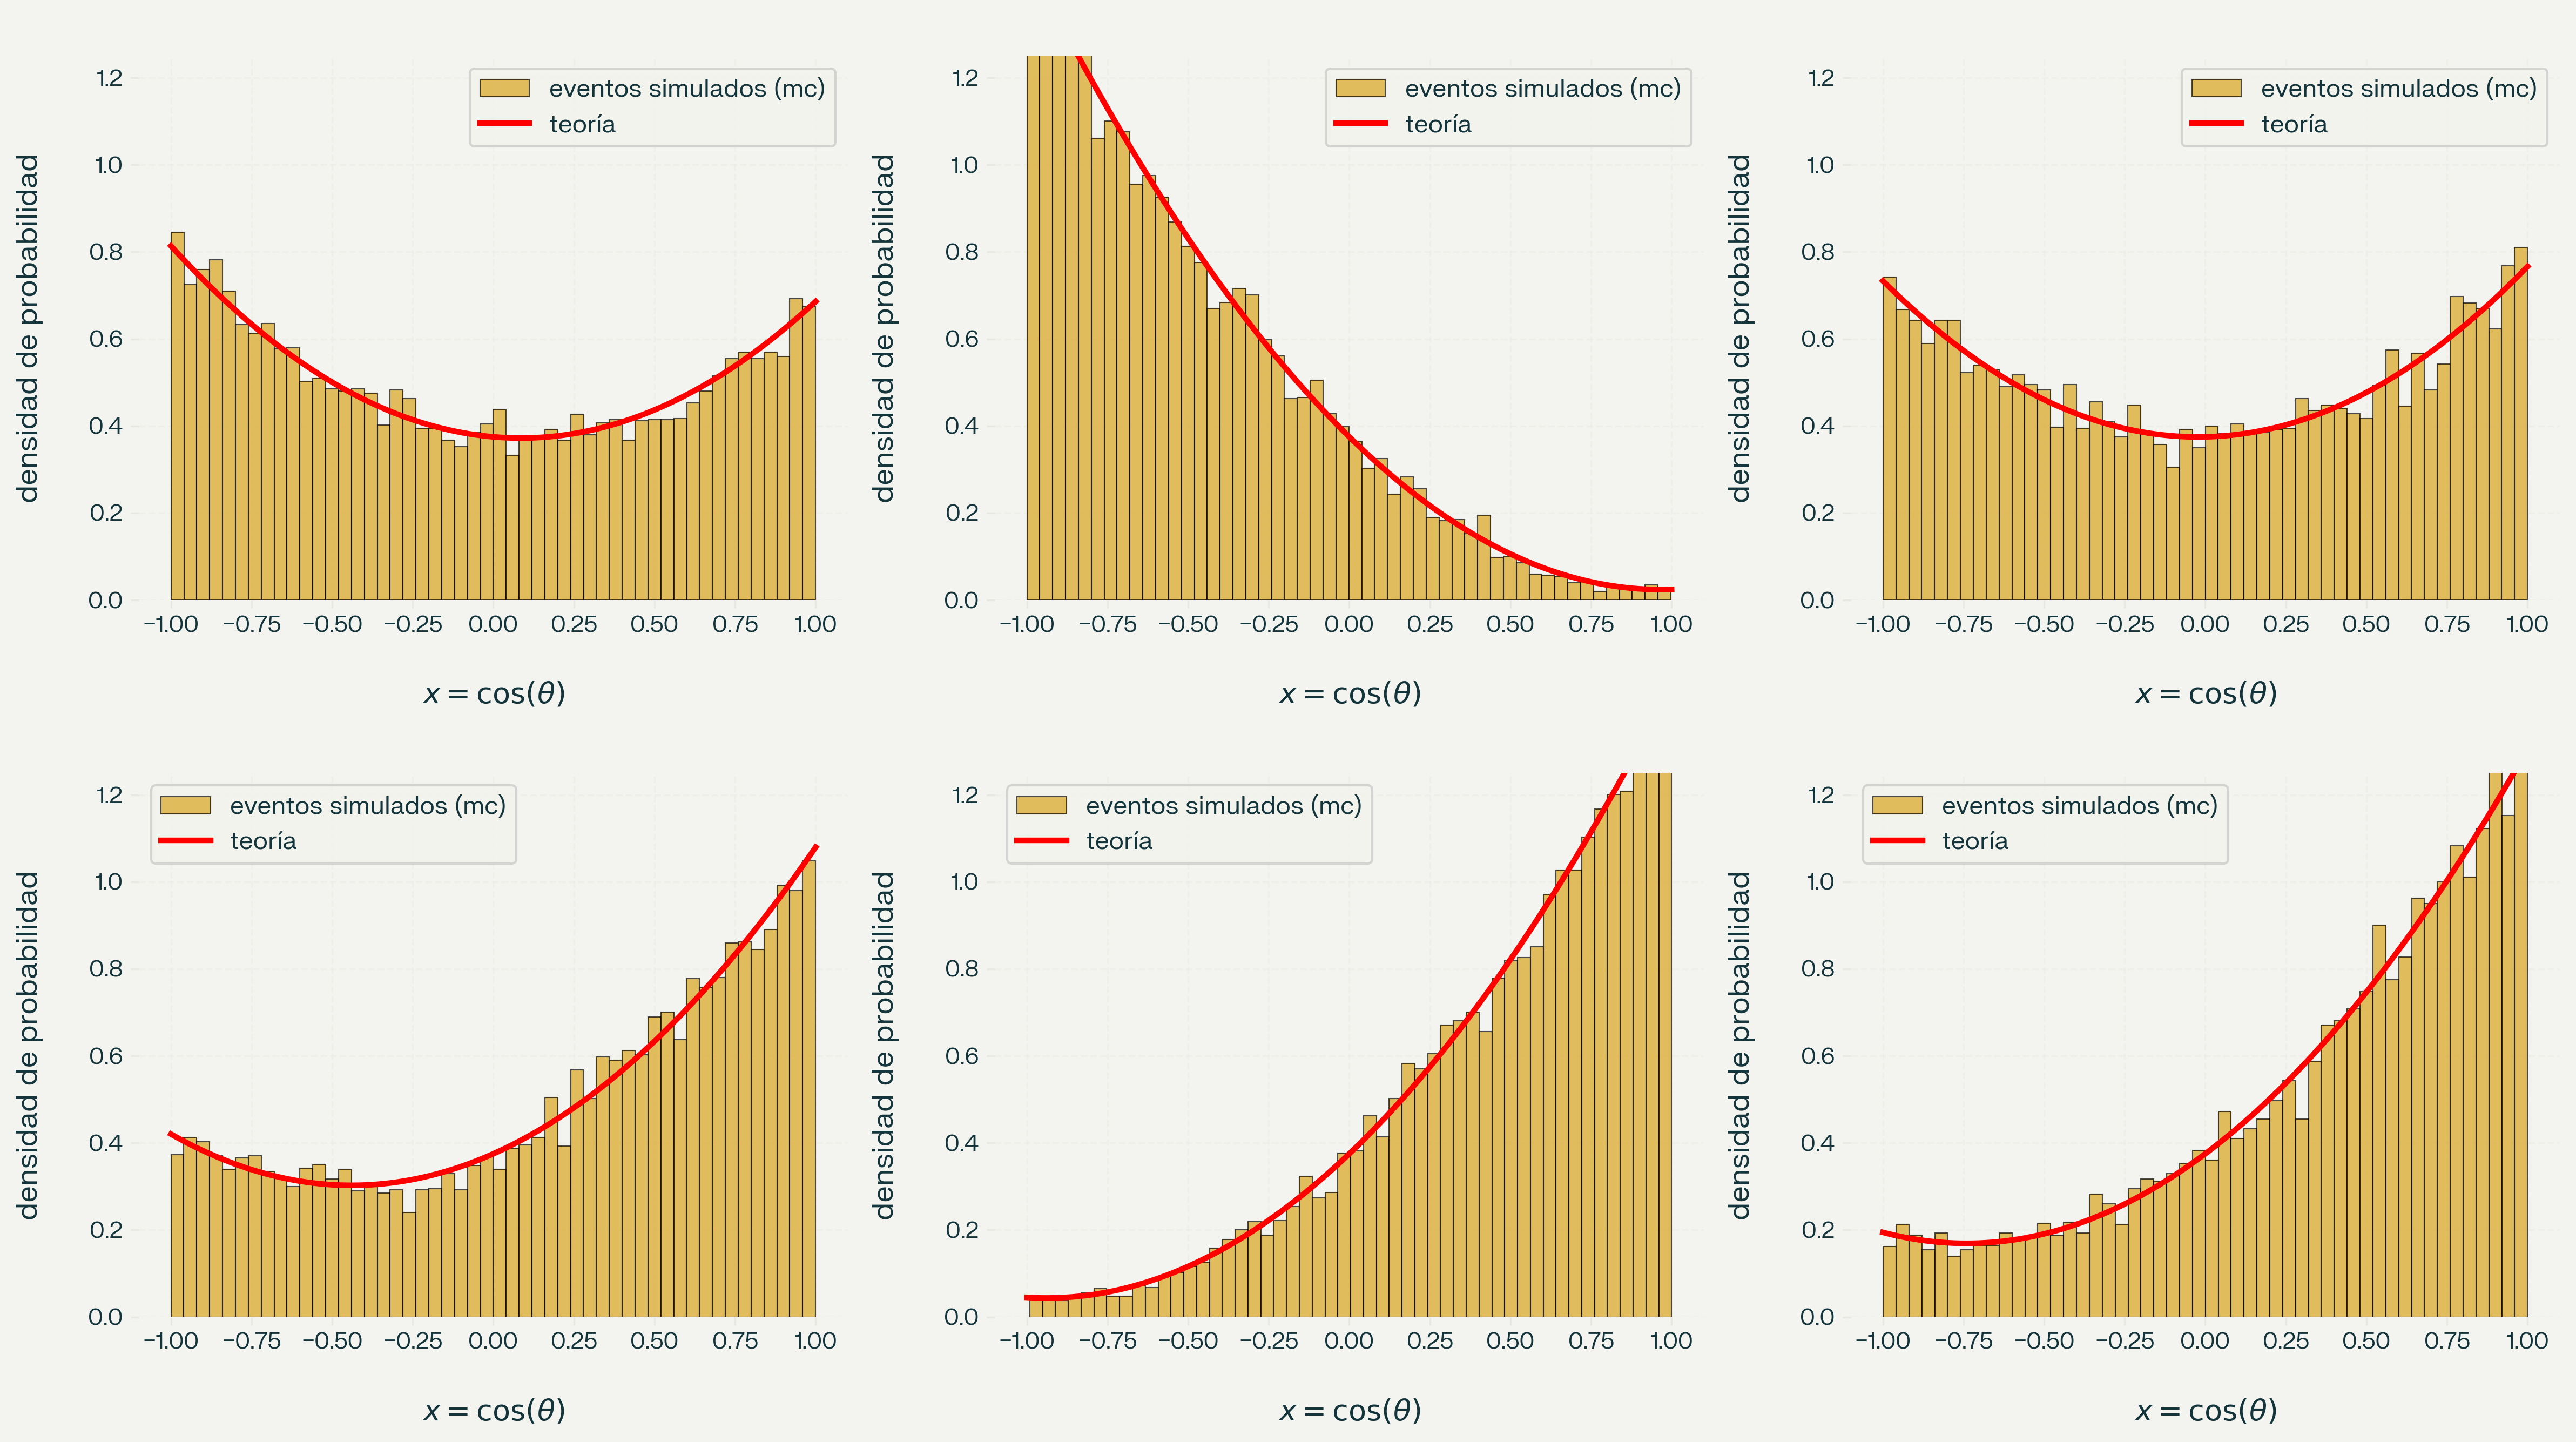

raiz_s =  30.0000 GeV   A_FB simulada = -0.0758   teórica = -0.0638
raiz_s =  80.0000 GeV   A_FB simulada = -0.7312   teórica = -0.7256
raiz_s =  91.1876 GeV   A_FB simulada = +0.0184   teórica = +0.0166
raiz_s =  95.0000 GeV   A_FB simulada = +0.3380   teórica = +0.3297
raiz_s = 105.0000 GeV   A_FB simulada = +0.7134   teórica = +0.7050
raiz_s = 200.0000 GeV   A_FB simulada = +0.5476   teórica = +0.5556


In [7]:
energias_demo = [30, 80, 91.1876, 95, 105, 200]

fig, ejes = plt.subplots(2, 3, figsize=(16, 9))
ejes = ejes.flatten()
resultados_E = []

for ax, E in zip(ejes, energias_demo):
    A_E_, B_E_ = coeficientes(E)
    ev, ef = rejection_sampling(A_E_, B_E_, n_events)
    afb_sim = asimetria_fb(ev)
    resultados_E.append((E, afb_sim, 3 * B_E_ / (8 * A_E_)))
    grafica_eventos(ax, ev, A_E_, B_E_, 'teoría',
                    rf'$\sqrt{{s}}={E}$ GeV   $A_{{FB}}$={afb_sim:+.3f}', bins=50)
    ax.set_ylim(0, 1.25)

plt.tight_layout()
plt.show()

for E, sim, teo in resultados_E:
    print(f"raiz_s = {E:8.4f} GeV   A_FB simulada = {sim:+.4f}   teórica = {teo:+.4f}")

Observaciones:

- a $\sqrt{s}=30$ GeV domina el fotón: la distribución es casi la simétrica y $A_{FB}$ es chica y negativa
- cerca de la resonancia ($80$–$95$ GeV) la interferencia $\gamma$–$Z$ se intensifica y la curva se inclina: primero hacia *backward* (debajo del polo) y luego hacia *forward* (arriba)
- en $m_Z$ la interferencia es nula ($\mathrm{Re}\,\chi=0$) y la asimetría remanente proviene del término $ZZ$, que es pequeña
- por encima de la resonancia la distribución es claramente asimétrica hacia $x>0$, con $A_{FB}\approx0.7$ a 105 GeV

A continuación se comparan, a la izquierda, las curvas teóricas de $f(x)$ normalizadas para varias energías y, a la derecha, la $A_{FB}$ teórica contra simulaciones en un barrido de energía (10 000 eventos por punto, barra de error $\sqrt{(1-A_{FB}^2)/N}$).

/usr/local/lib/python3.12/site-packages/pydantic/main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `LineChart` - serialized value may not be as expected [input_value=Chart(type=<ChartType.UNK...mulación', elements=[]), input_type=Chart])
  PydanticSerializationUnexpectedValue(Expected `ScatterChart` - serialized value may not be as expected [input_value=Chart(type=<ChartType.UNK...mulación', elements=[]), input_type=Chart])
  PydanticSerializationUnexpectedValue(Expected `BarChart` - serialized value may not be as expected [input_value=Chart(type=<ChartType.UNK...mulación', elements=[]), input_type=Chart])
  PydanticSerializationUnexpectedValue(Expected `PieChart` - serialized value may not be as expected [input_value=Chart(type=<ChartType.UNK...mulación', elements=[]), input_type=Chart])
  PydanticSerializationUnexpectedValue(Expected `BoxAndWhiskerChart` - serialized value may not be as expected [input_value=Chart(type=<ChartType.

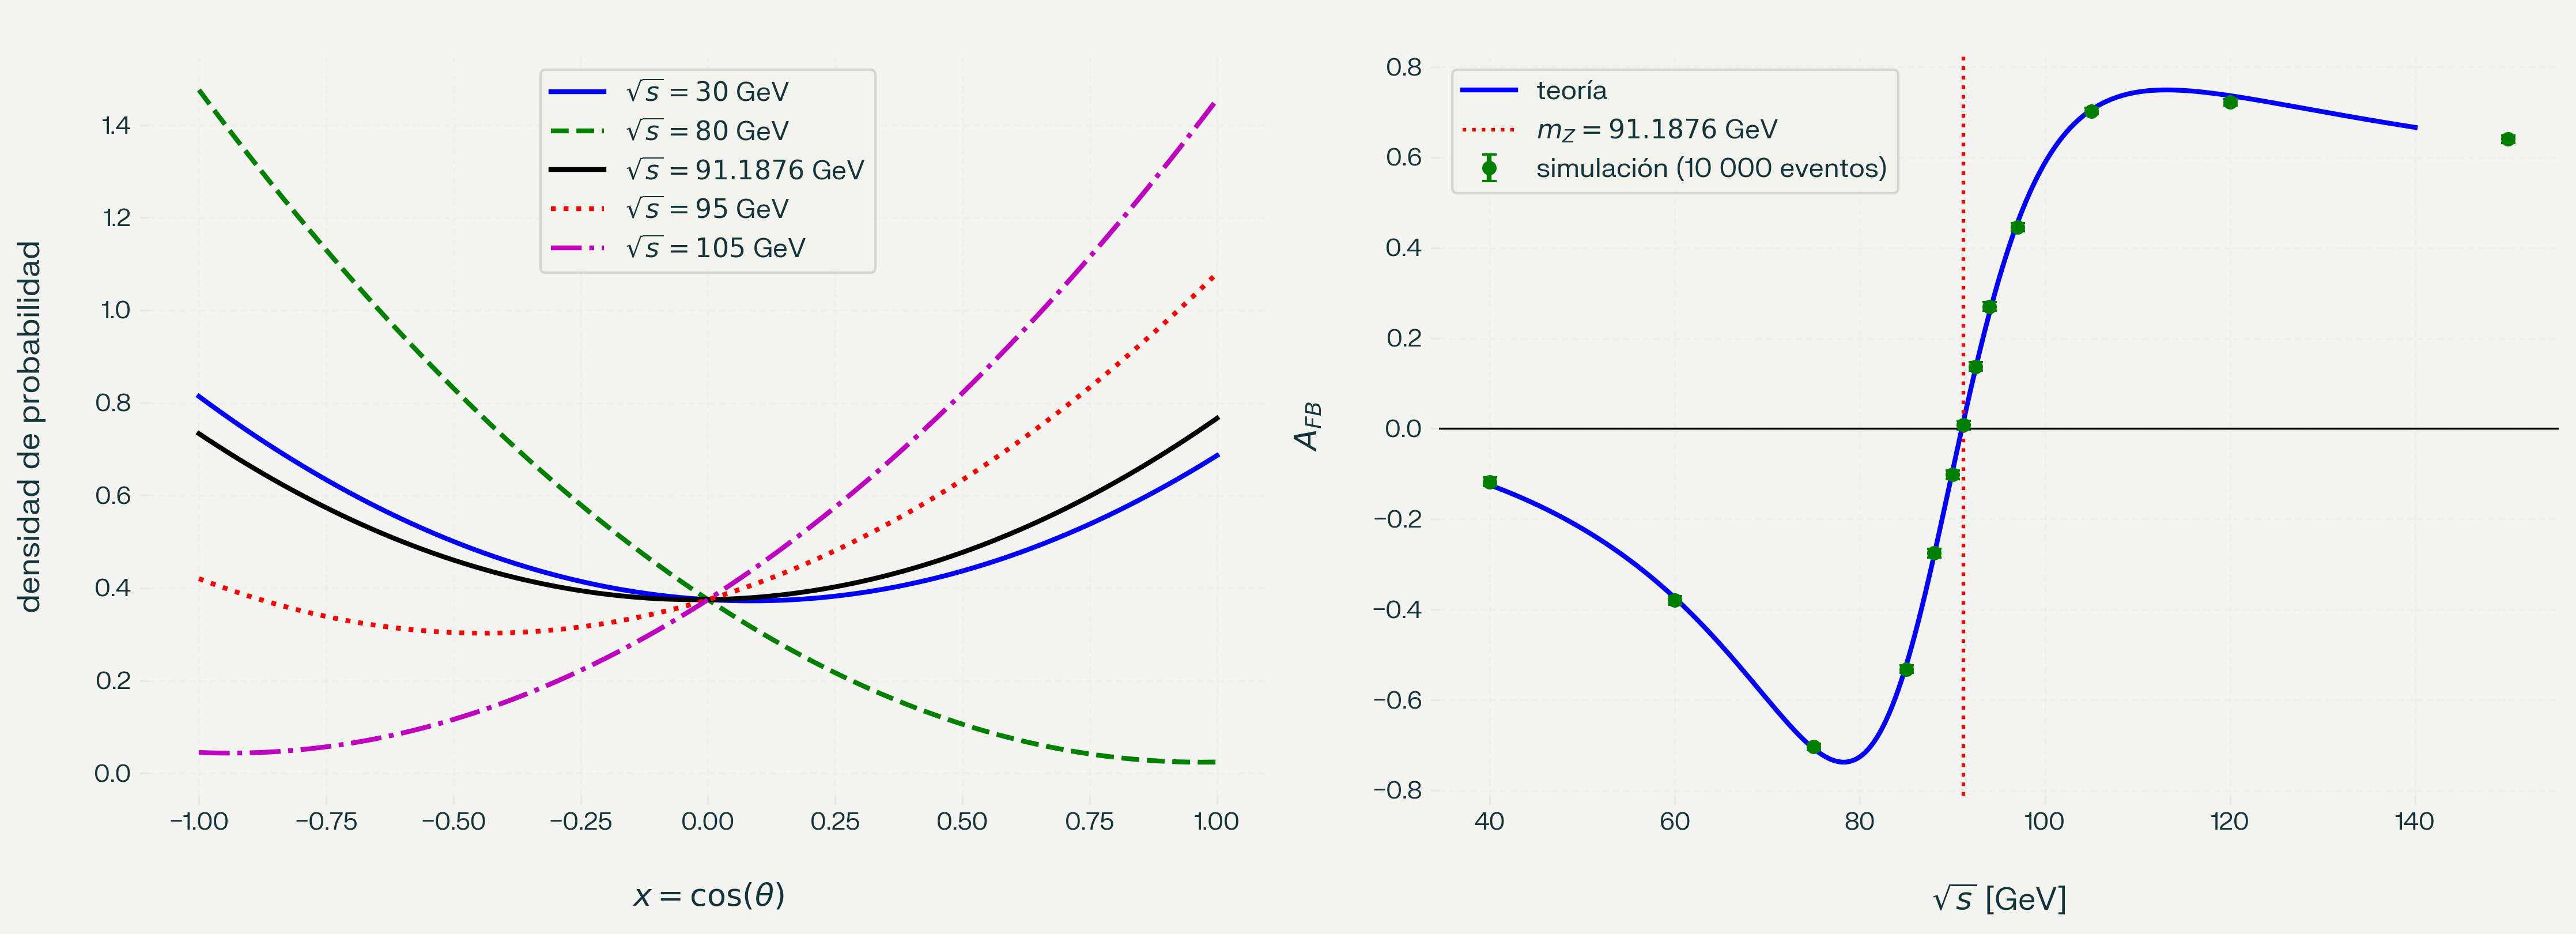

In [8]:
energias_scan = np.array([40, 60, 75, 85, 88, 90, 91.1876, 92.5, 94, 97, 105, 120, 150])
afb_mc, err_mc = [], []
for E in energias_scan:
    A_E_, B_E_ = coeficientes(E)
    ev, _ = rejection_sampling(A_E_, B_E_, n_events)
    afb = asimetria_fb(ev)
    afb_mc.append(afb)
    err_mc.append(error_afb(afb, n_events))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
x_t = np.linspace(-1, 1, 500)
estilos = [('b-', 30), ('g--', 80), ('k-', m_Z), ('r:', 95), ('m-.', 105)]
for est, E in estilos:
    A_, B_ = coeficientes(E)
    y_ = f(x_t, A_, B_)
    ax.plot(x_t, y_ / np.trapz(y_, x_t), est, linewidth=2, label=rf'$\sqrt{{s}}={E:g}$ GeV')
ax.set_xlabel(r'$x = \cos(\theta)$', fontsize=13)
ax.set_ylabel('densidad de probabilidad', fontsize=13)
ax.set_title('Forma de $f(x)$ a distintas energías', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

ax = axes[1]
ax.plot(ECM_vals, afb_E, 'b-', linewidth=2, label='teoría')
ax.errorbar(energias_scan, afb_mc, yerr=err_mc, fmt='o', color='green', ecolor='green',
            capsize=3, markersize=5, label='simulación (10 000 eventos)')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(m_Z, color='red', linestyle=':', linewidth=1.5, label=f'$m_Z = {m_Z}$ GeV')
ax.set_xlabel(r'$\sqrt{s}$ [GeV]', fontsize=13)
ax.set_ylabel(r'$A_{FB}$', fontsize=13)
ax.set_title('Forward-Backward asymmetry: teoría vs simulación', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## ***9. Sensibilidad del método para extraer parámetros***

Se evalúa qué tan bien el método Monte Carlo recupera un parámetro físico, en este caso $\sin^2\theta_W$. El procedimiento es:

1. generar un "experimento" con un valor verdadero ($\sin^2\theta_W=0.23126$)
2. medir $A_{FB}$ con los eventos
3. invertir la curva teórica $A_{FB}(\sin^2\theta_W)$ para estimar $\sin^2\theta_W$
4. repetir muchas veces y cuantificar la dispersión

### ***a) el error de $A_{FB}$ decrece como $1/\sqrt{N}$***

El experimento se repite 100 veces en el polo de la $Z$ para distintos $N$.

N =    1000   A_FB media = +0.0106   desviación = 0.0260   1/sqrt(N) = 0.0316
N =   10000   A_FB media = +0.0169   desviación = 0.0099   1/sqrt(N) = 0.0100


N =  100000   A_FB media = +0.0169   desviación = 0.0031   1/sqrt(N) = 0.0032


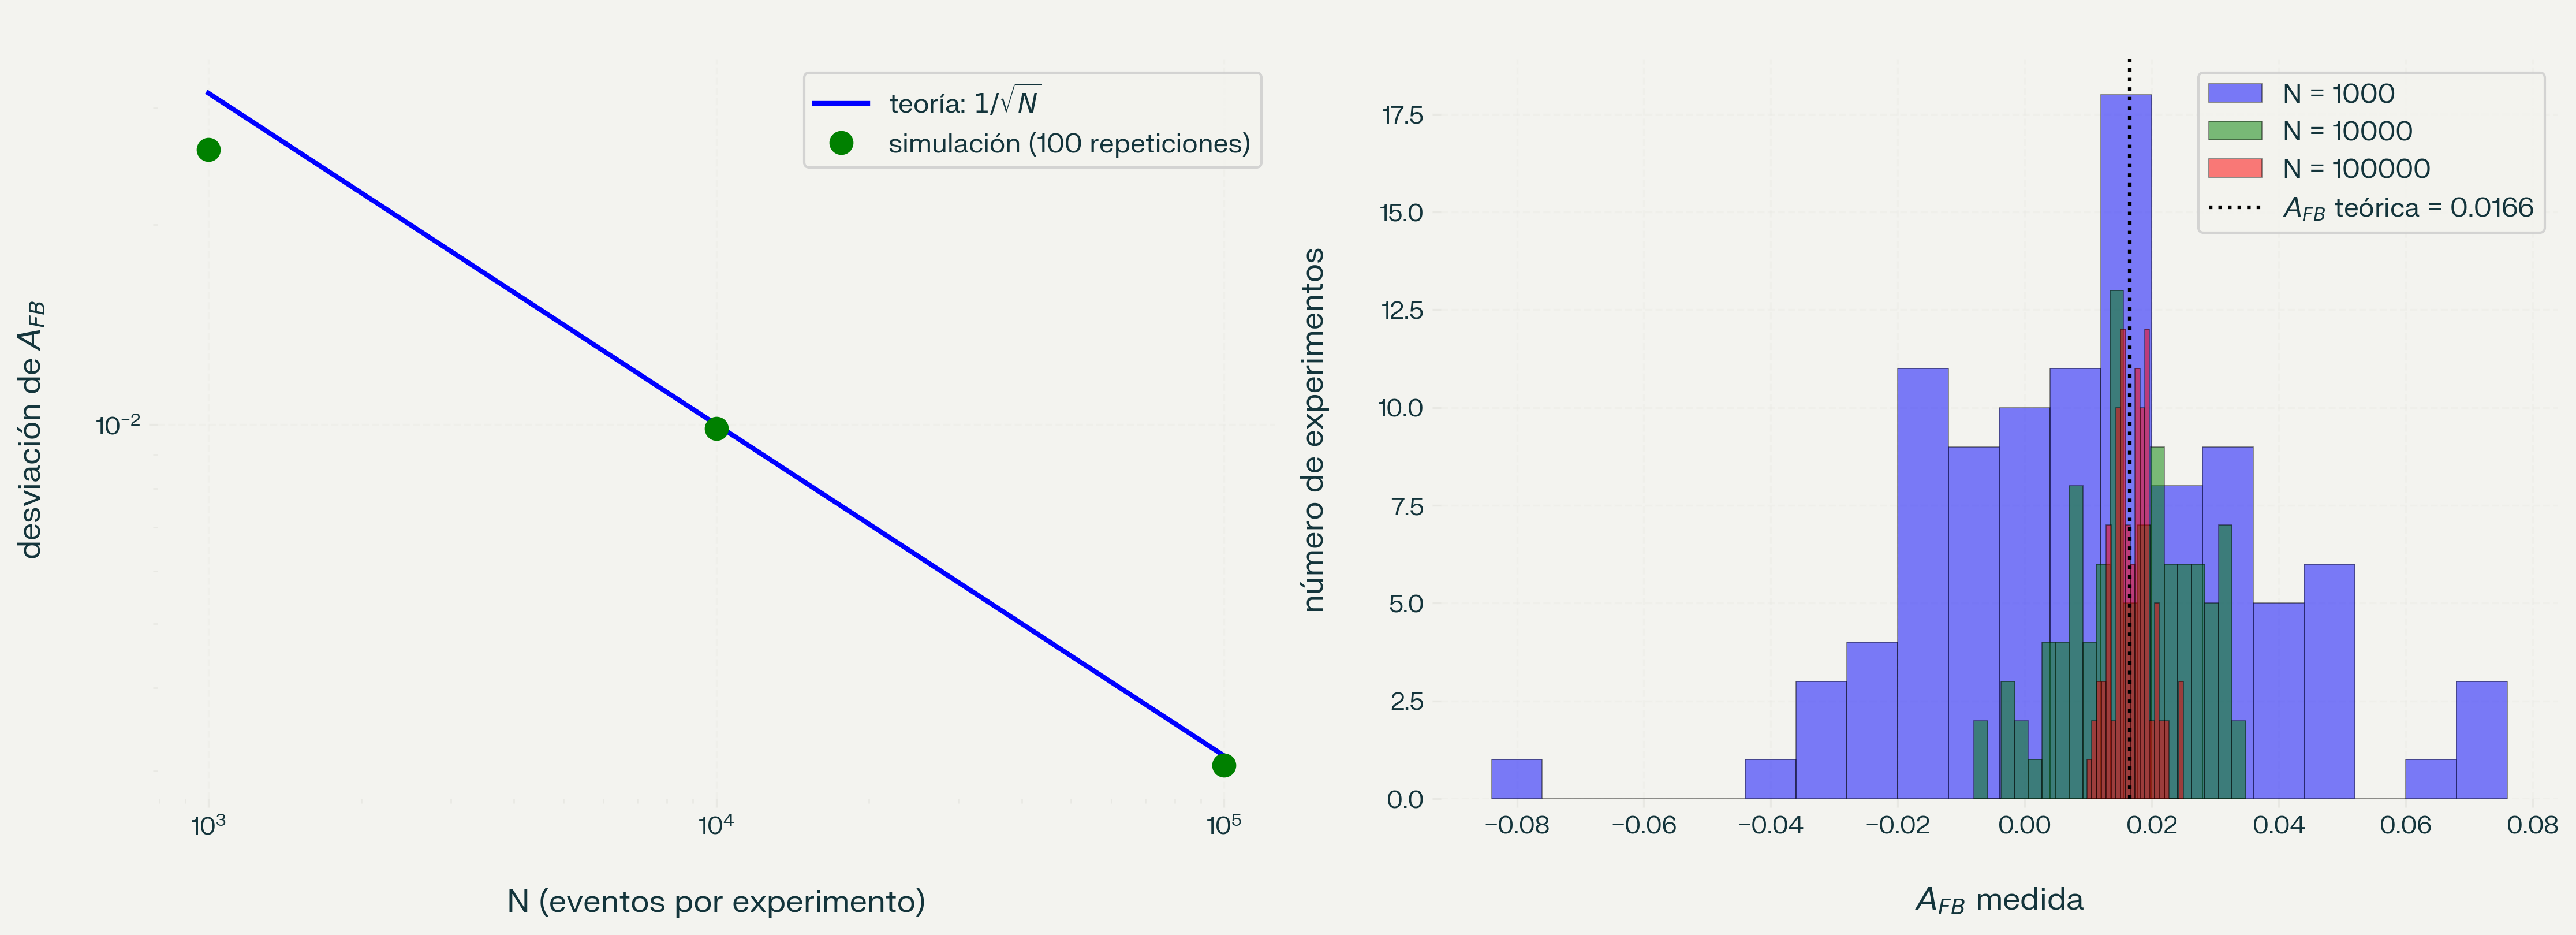

In [9]:
n_rep = 100
tamanos = [1000, 10000, 100000]
A_p, B_p = coeficientes(m_Z)
medidas_afb, dispersion = {}, []

np.random.seed(1)
for N in tamanos:
    medidas = np.array([asimetria_fb(rejection_sampling(A_p, B_p, N)[0]) for _ in range(n_rep)])
    medidas_afb[N] = medidas
    dispersion.append(np.std(medidas))
    print(f"N = {N:7d}   A_FB media = {np.mean(medidas):+.4f}   desviación = {np.std(medidas):.4f}   1/sqrt(N) = {1/np.sqrt(N):.4f}")

N_arr = np.array(tamanos)
N_fino = np.logspace(3, 5, 50)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
ax.plot(N_fino, 1 / np.sqrt(N_fino), 'b-', linewidth=2, label=r'teoría: $1/\sqrt{N}$')
ax.plot(N_arr, dispersion, 'go', markersize=9, label='simulación (100 repeticiones)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('N (eventos por experimento)', fontsize=13)
ax.set_ylabel(r'desviación de $A_{FB}$', fontsize=13)
ax.set_title(r'Error estadístico de $A_{FB}$ en $\sqrt{s}=m_Z$', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

ax = axes[1]
for N, col in zip(tamanos, ['b', 'g', 'r']):
    ax.hist(medidas_afb[N], bins=20, alpha=0.5, color=col, edgecolor='black', linewidth=0.4,
            label=f'N = {N}')
ax.axvline(afb_teorica(m_Z), color='black', linestyle=':', linewidth=1.5,
           label=rf'$A_{{FB}}$ teórica = {afb_teorica(m_Z):.4f}')
ax.set_xlabel(r'$A_{FB}$ medida', fontsize=13)
ax.set_ylabel('número de experimentos', fontsize=13)
ax.set_title('Las medidas se concentran al aumentar N', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

### ***b) energía óptima para medir $\sin^2\theta_W$***

Lo relevante es cuánto cambia $A_{FB}$ al cambiar $\sin^2\theta_W$, es decir la derivada $\partial A_{FB}/\partial\sin^2\theta_W$. Si es grande, un error pequeño en $A_{FB}$ produce un error pequeño en $\sin^2\theta_W$:

$$\sigma_{\sin^2\theta_W}\approx\frac{\sigma_{A_{FB}}}{\left|\partial A_{FB}/\partial\sin^2\theta_W\right|}$$

La derivada se calcula numéricamente (diferencia finita) para cada energía.

raiz_s =  60.0000 GeV   dA_FB/d(sin2w) =   +0.939   --> error en sin2w con 1/sqrt(N)=0.003: 0.0032
raiz_s =  85.0000 GeV   dA_FB/d(sin2w) =   -2.925   --> error en sin2w con 1/sqrt(N)=0.003: 0.0010
raiz_s =  91.1876 GeV   dA_FB/d(sin2w) =   -1.749   --> error en sin2w con 1/sqrt(N)=0.003: 0.0017
raiz_s =  95.0000 GeV   dA_FB/d(sin2w) =   -0.384   --> error en sin2w con 1/sqrt(N)=0.003: 0.0078
raiz_s = 105.0000 GeV   dA_FB/d(sin2w) =   +0.462   --> error en sin2w con 1/sqrt(N)=0.003: 0.0065
raiz_s = 150.0000 GeV   dA_FB/d(sin2w) =   -0.932   --> error en sin2w con 1/sqrt(N)=0.003: 0.0032


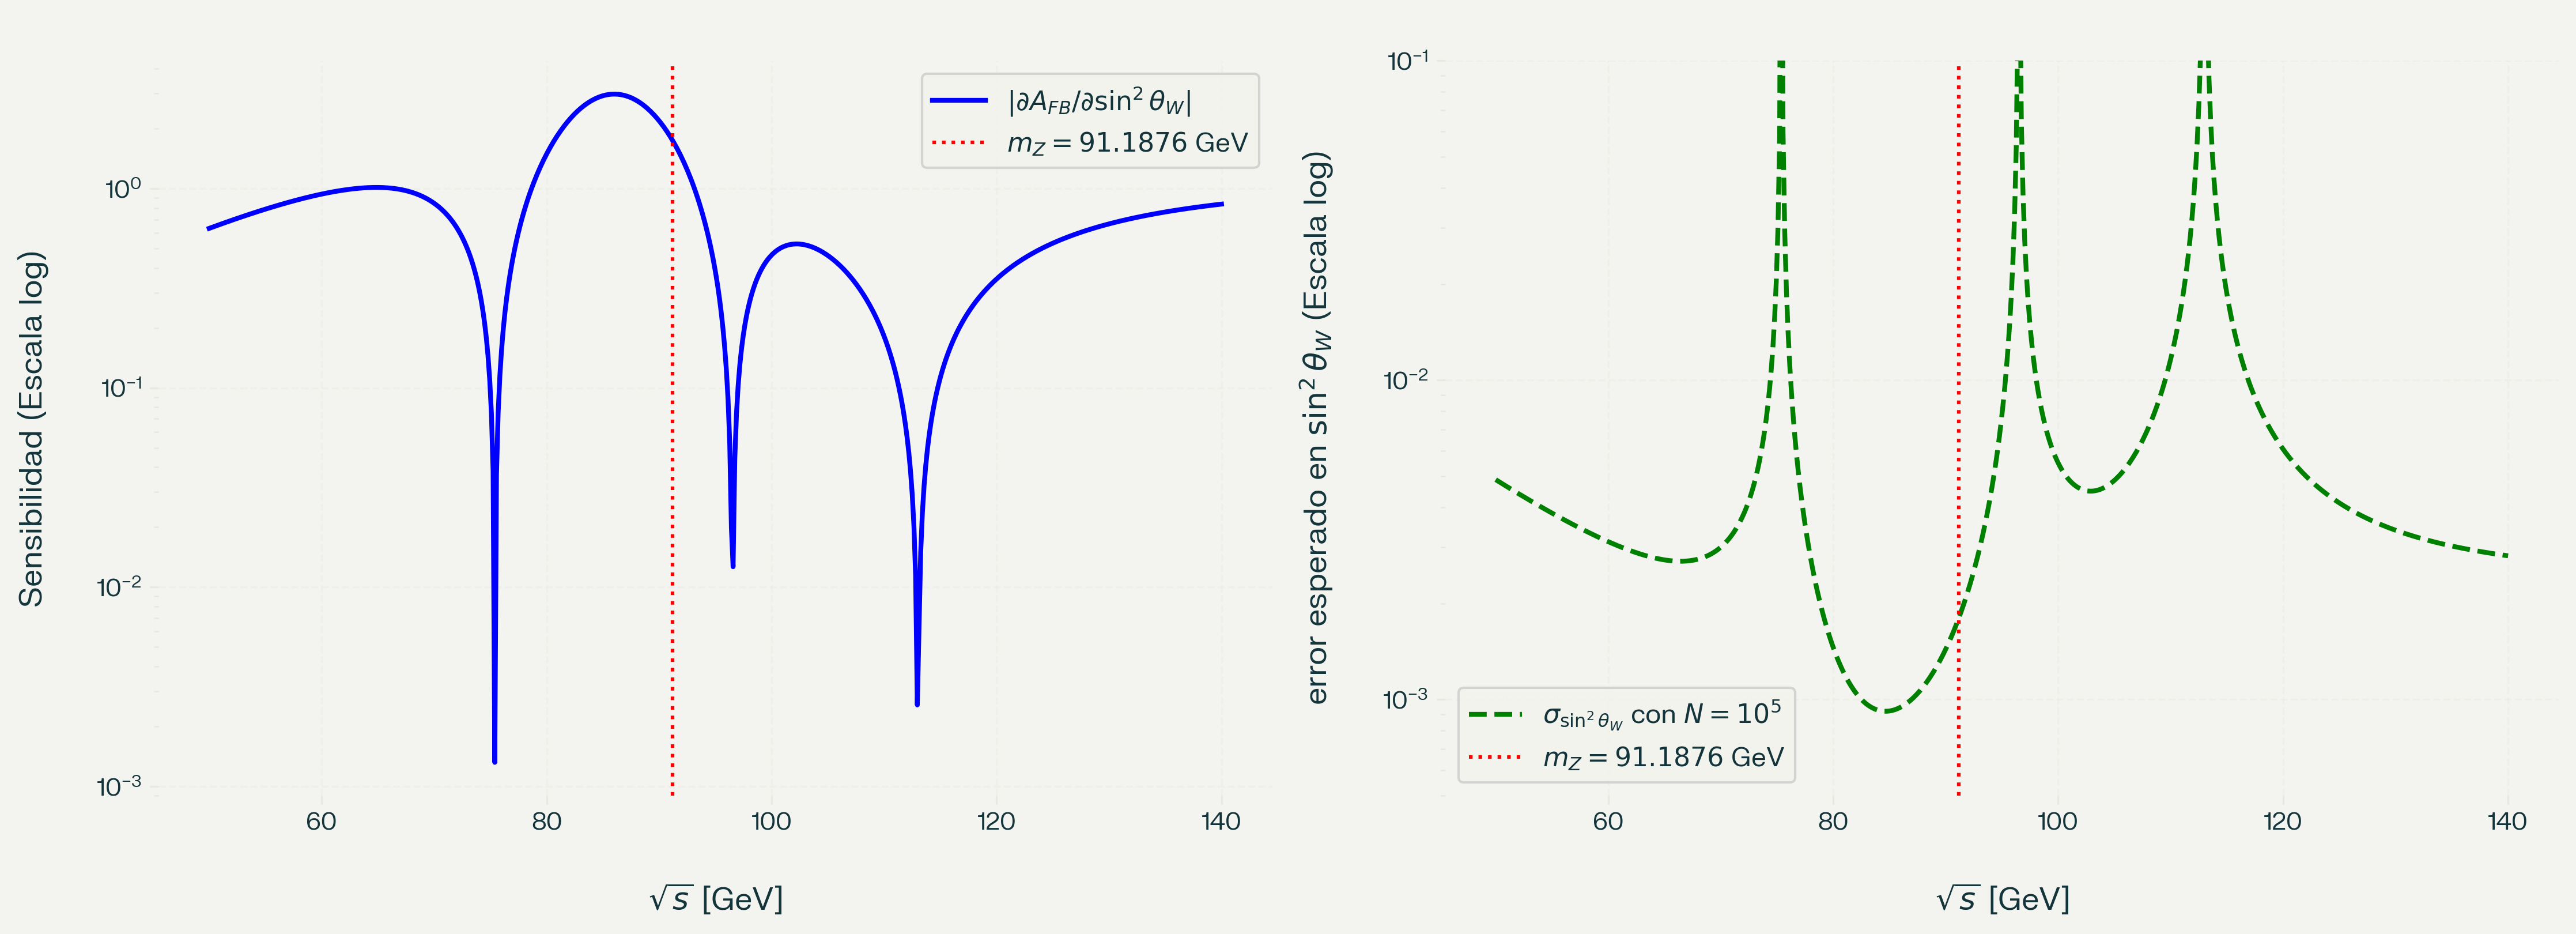

In [10]:
h = 1e-4
def derivada_afb(E):
    return (afb_teorica(E, s2w + h) - afb_teorica(E, s2w - h)) / (2 * h)

for E in [60, 85, 91.1876, 95, 105, 150]:
    d = derivada_afb(E)
    print(f"raiz_s = {E:8.4f} GeV   dA_FB/d(sin2w) = {d:+8.3f}   --> error en sin2w con 1/sqrt(N)=0.003: {0.003/abs(d):.4f}")

E_sens = np.linspace(50, 140, 600)
deriv_E = np.array([derivada_afb(E) for E in E_sens])
afb_sens = np.array([afb_teorica(E) for E in E_sens])
N_ref = 100000
sigma_s2w = np.sqrt((1 - afb_sens**2) / N_ref) / np.abs(deriv_E)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
ax.plot(E_sens, np.abs(deriv_E), 'b-', linewidth=2, label=r'$|\partial A_{FB}/\partial \sin^2\theta_W|$')
ax.axvline(m_Z, color='red', linestyle=':', linewidth=1.5, label=f'$m_Z = {m_Z}$ GeV')
ax.set_yscale('log')
ax.set_xlabel(r'$\sqrt{s}$ [GeV]', fontsize=13)
ax.set_ylabel('Sensibilidad (Escala log)', fontsize=13)
ax.set_title(r'Dependencia de $A_{FB}$ respecto a $\sin^2\theta_W$', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

ax = axes[1]
ax.plot(E_sens, sigma_s2w, 'g--', linewidth=2, label=r'$\sigma_{\sin^2\theta_W}$ con $N=10^5$')
ax.axvline(m_Z, color='red', linestyle=':', linewidth=1.5, label=f'$m_Z = {m_Z}$ GeV')
ax.set_yscale('log')
ax.set_ylim(5e-4, 1e-1)
ax.set_xlabel(r'$\sqrt{s}$ [GeV]', fontsize=13)
ax.set_ylabel(r'error esperado en $\sin^2\theta_W$ (Escala log)', fontsize=13)
ax.set_title('Energía óptima de medición', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

La sensibilidad es máxima cerca del polo (la derivada vale $\approx-2.9$ a 85 GeV y $\approx-1.7$ en $m_Z$). Aunque $A_{FB}$ en $m_Z$ es pequeña, depende fuertemente de $\sin^2\theta_W$ porque $A_{FB}\propto(1-4\sin^2\theta_W)^2$ y ese factor casi se anula. Por encima de la resonancia (95–105 GeV) $A_{FB}$ es grande pero casi independiente de $\sin^2\theta_W$, y con el mismo número de eventos el error resulta 4 o 5 veces mayor. Los picos de la curva derecha aparecen donde la derivada se anula.

### ***c) extracción de $\sin^2\theta_W$ en el polo***

Se construye la curva $A_{FB}(\sin^2\theta_W)$ y se invierte por interpolación en un intervalo donde es monótona ($0.20$ a $0.245$).

N =    1000   sin2w = 0.2316 +- 0.0119   (valor verdadero 0.23126)
N =   10000   sin2w = 0.2325 +- 0.0062   (valor verdadero 0.23126)


N =  100000   sin2w = 0.2313 +- 0.0020   (valor verdadero 0.23126)


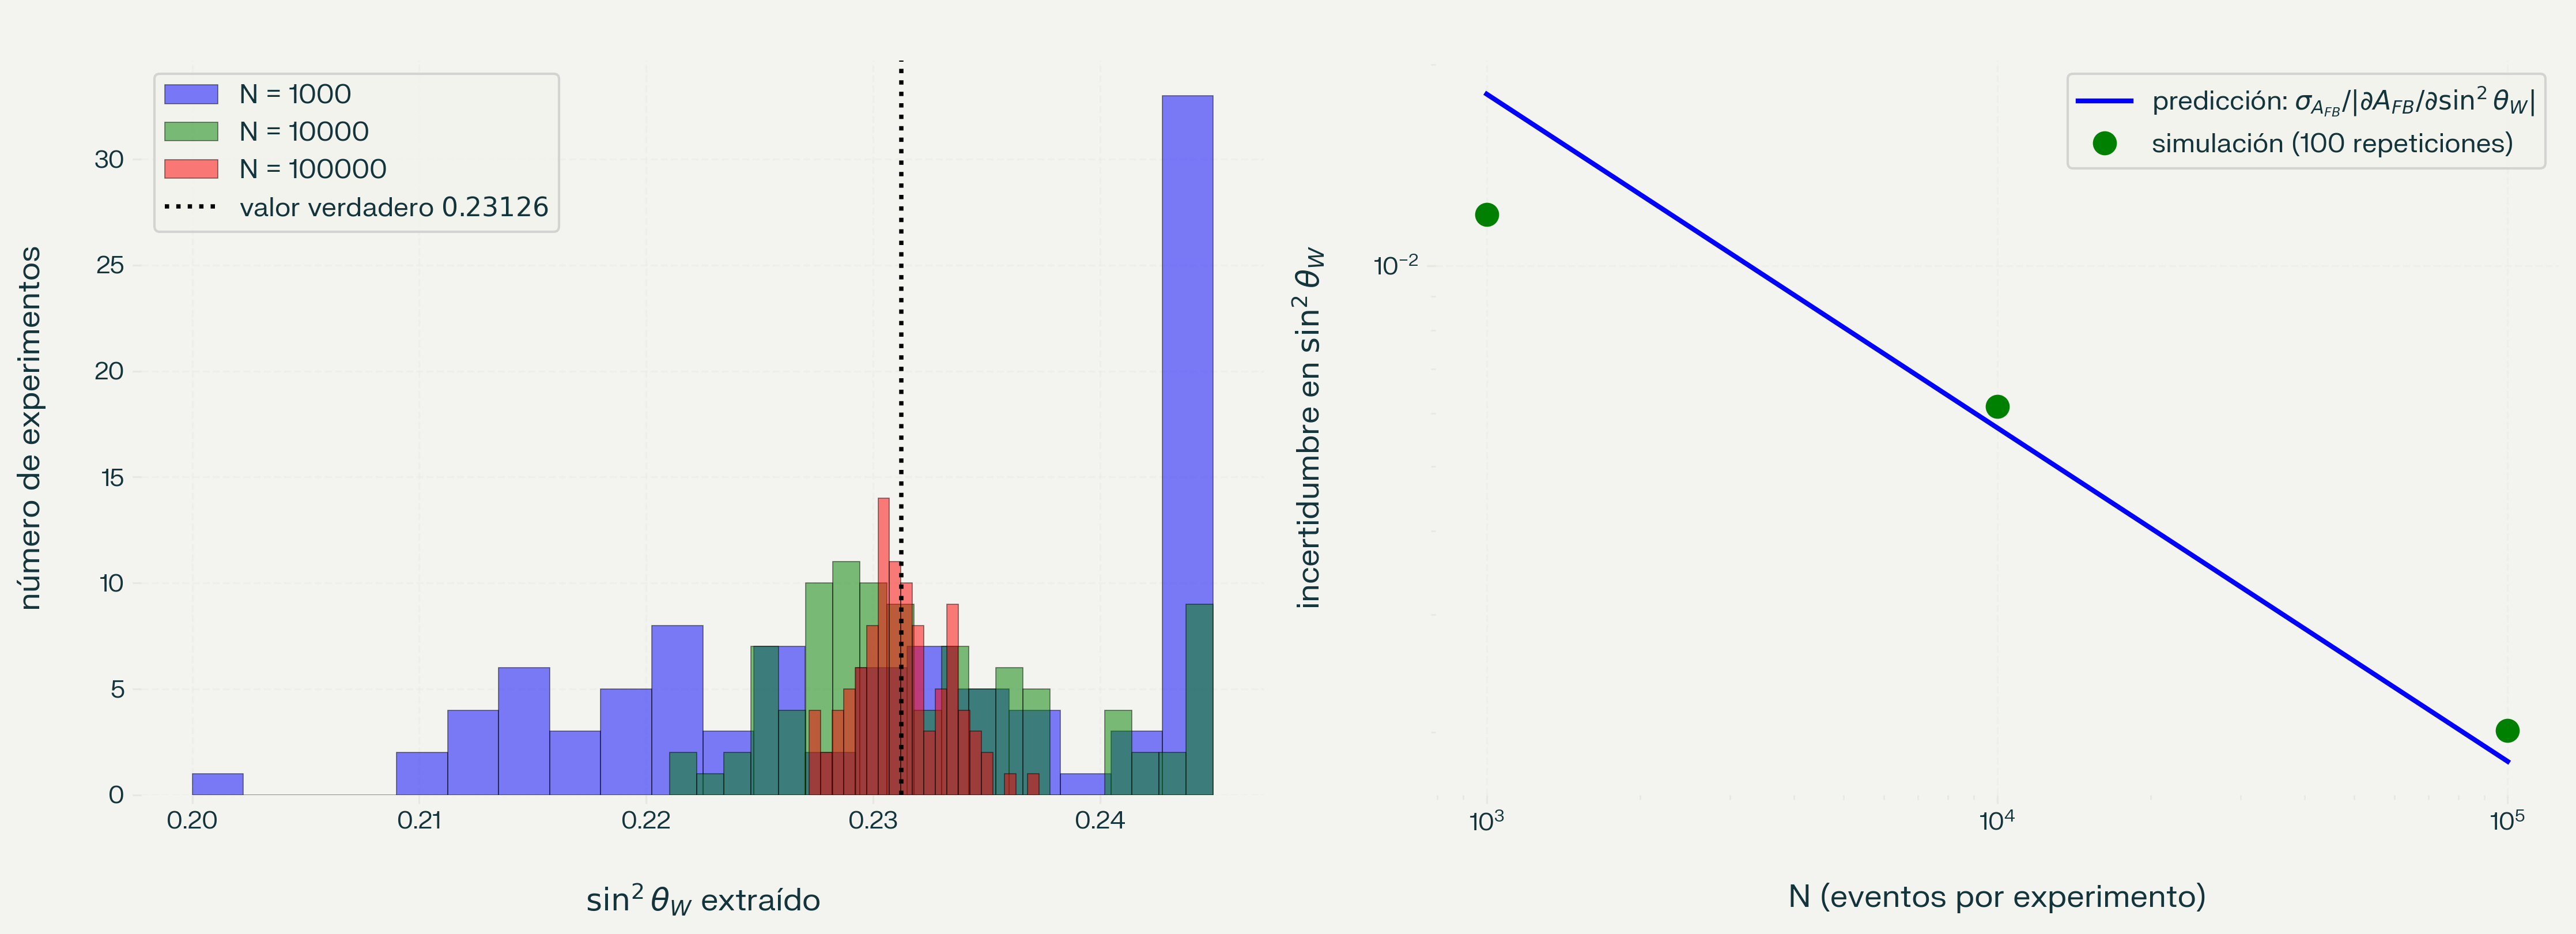

In [11]:
rejilla = np.linspace(0.20, 0.245, 200)
afb_rejilla = np.array([afb_teorica(m_Z, v) for v in rejilla])

def extraer_s2w(afb_medida):
    '''invierte A_FB(sin2w): la curva decrece, así que se invierte el orden para np.interp'''
    return np.interp(afb_medida, afb_rejilla[::-1], rejilla[::-1])

resultados = {}
np.random.seed(7)
for N in tamanos:
    estimados = []
    for _ in range(n_rep):
        ev, _ = rejection_sampling(A_p, B_p, N)
        estimados.append(extraer_s2w(asimetria_fb(ev)))
    resultados[N] = np.array(estimados)
    print(f"N = {N:7d}   sin2w = {np.mean(estimados):.4f} +- {np.std(estimados):.4f}   (valor verdadero {s2w})")

sig_sim = [np.std(resultados[N]) for N in tamanos]
sig_teo = [error_afb(afb_teorica(m_Z), N) / abs(derivada_afb(m_Z)) for N in N_fino]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
for N, col in zip(tamanos, ['b', 'g', 'r']):
    ax.hist(resultados[N], bins=20, alpha=0.5, color=col, edgecolor='black', linewidth=0.4,
            label=f'N = {N}')
ax.axvline(s2w, color='black', linestyle=':', linewidth=1.8, label=r'valor verdadero $0.23126$')
ax.set_xlabel(r'$\sin^2\theta_W$ extraído', fontsize=13)
ax.set_ylabel('número de experimentos', fontsize=13)
ax.set_title(r'Recuperación de $\sin^2\theta_W$ con Monte Carlo', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

ax = axes[1]
ax.plot(N_fino, sig_teo, 'b-', linewidth=2, label=r'predicción: $\sigma_{A_{FB}}/|\partial A_{FB}/\partial\sin^2\theta_W|$')
ax.plot(N_arr, sig_sim, 'go', markersize=9, label='simulación (100 repeticiones)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('N (eventos por experimento)', fontsize=13)
ax.set_ylabel(r'incertidumbre en $\sin^2\theta_W$', fontsize=13)
ax.set_title('Precisión del método vs número de eventos', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## ***10. CASO: para cada ángulo de 0° a 180°***

### ***Averiguar cuántas partículas entran en cada grado***

Este es el último punto del plan. Para cada evento se tiene $x=\cos\theta$, que se convierte a ángulo con

$$\theta=\arccos(x)\quad(\text{en grados}),$$

y se cuenta cuántos eventos caen en cada intervalo de $1^\circ$:

$$k^\circ\le\theta<(k+1)^\circ,\qquad k=0,1,2,\dots,179$$

El último intervalo ($179^\circ$–$180^\circ$) incluye también el $180^\circ$ exacto. Son **180 intervalos** y la suma de todos debe dar $N=10\,000$, lo que sirve de comprobación de que no se perdió ningún evento.

El conteo se hace primero de forma directa con un ciclo `for` sobre los 180 grados y después se verifica con `np.histogram`.

In [12]:
def particulas_por_grado(eventos):
    '''cuenta cuántas partículas hay en cada intervalo [k, k+1) grados, k = 0, ..., 179'''
    theta = np.degrees(np.arccos(np.clip(eventos, -1, 1)))    # x -> theta en grados
    cuentas = np.zeros(180, dtype=int)
    for k in range(180):
        if k < 179:
            en_el_grado = (theta >= k) & (theta < k + 1)
        else:
            en_el_grado = (theta >= k) & (theta <= k + 1)      # el último incluye 180°
        cuentas[k] = np.sum(en_el_grado)
    return cuentas, theta

def esperado_por_grado(A, B, n):
    '''predicción de la teoría para cada grado: n * P(k < theta < k+1)'''
    grados_ = np.arange(0, 181, 1)
    F = lambda x: A * (x + x**3 / 3) + B * x**2 / 2           # primitiva de f(x)
    xb = np.cos(np.radians(grados_))
    return n * (F(xb[:-1]) - F(xb[1:])) / (F(1) - F(-1))

casos = [("Distribución simétrica (solo fotón)", ev_sim, A_sim, B_sim),
         ("Asimetría propuesta", ev_ideal, A_ideal, B_ideal),
         (r"Corrientes neutras, $\sqrt{s}=m_Z$", ev_nc, A_NC, B_NC)]

grados = np.arange(180) + 0.5            # centro de cada intervalo
columnas = []
for nombre, ev, A_, B_ in casos:
    cuentas, theta = particulas_por_grado(ev)
    cuentas_np, _ = np.histogram(theta, bins=np.arange(0, 181, 1))   # verificación
    print(f"{nombre}")
    print(f"   total contado = {cuentas.sum()} de {len(ev)} eventos")
    print(f"   coincide con np.histogram: {np.array_equal(cuentas, cuentas_np)}")
    print(f"   intervalo más poblado: {np.argmax(cuentas)}° - {np.argmax(cuentas)+1}° ({cuentas.max()} partículas)")
    print(f"   intervalo menos poblado: {np.argmin(cuentas)}° - {np.argmin(cuentas)+1}° ({cuentas.min()} partículas)")
    columnas.append(cuentas)

Distribución simétrica (solo fotón)
   total contado = 10000 de 10000 eventos
   coincide con np.histogram: True
   intervalo más poblado: 101° - 102° (93 partículas)
   intervalo menos poblado: 0° - 1° (1 partículas)
Asimetría propuesta
   total contado = 10000 de 10000 eventos
   coincide con np.histogram: True
   intervalo más poblado: 58° - 59° (110 partículas)
   intervalo menos poblado: 178° - 179° (2 partículas)
Corrientes neutras, $\sqrt{s}=m_Z$
   total contado = 10000 de 10000 eventos
   coincide con np.histogram: True
   intervalo más poblado: 51° - 52° (92 partículas)
   intervalo menos poblado: 179° - 180° (0 partículas)


### ***gráficas: partículas por grado***

Cada barra corresponde a un grado y la curva roja es la predicción teórica (integrando $f$ entre $\cos k^\circ$ y $\cos(k+1)^\circ$).

Debido al cambio de variable, $dx=\sin\theta\,d\theta$, se cumple $\dfrac{dN}{d\theta}=\dfrac{dN}{dx}\sin\theta$. Por eso la forma no coincide con la del histograma en $x$: cerca de $0^\circ$ y $180^\circ$ hay pocas partículas por grado aunque en $x$ haya muchas, ya que ahí un grado ocupa muy poco $\Delta x$.

/usr/local/lib/python3.12/site-packages/pydantic/main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `LineChart` - serialized value may not be as expected [input_value=Chart(type=<ChartType.UNK...o fotón)', elements=[]), input_type=Chart])
  PydanticSerializationUnexpectedValue(Expected `ScatterChart` - serialized value may not be as expected [input_value=Chart(type=<ChartType.UNK...o fotón)', elements=[]), input_type=Chart])
  PydanticSerializationUnexpectedValue(Expected `BarChart` - serialized value may not be as expected [input_value=Chart(type=<ChartType.UNK...o fotón)', elements=[]), input_type=Chart])
  PydanticSerializationUnexpectedValue(Expected `PieChart` - serialized value may not be as expected [input_value=Chart(type=<ChartType.UNK...o fotón)', elements=[]), input_type=Chart])
  PydanticSerializationUnexpectedValue(Expected `BoxAndWhiskerChart` - serialized value may not be as expected [input_value=Chart(type=<ChartType.

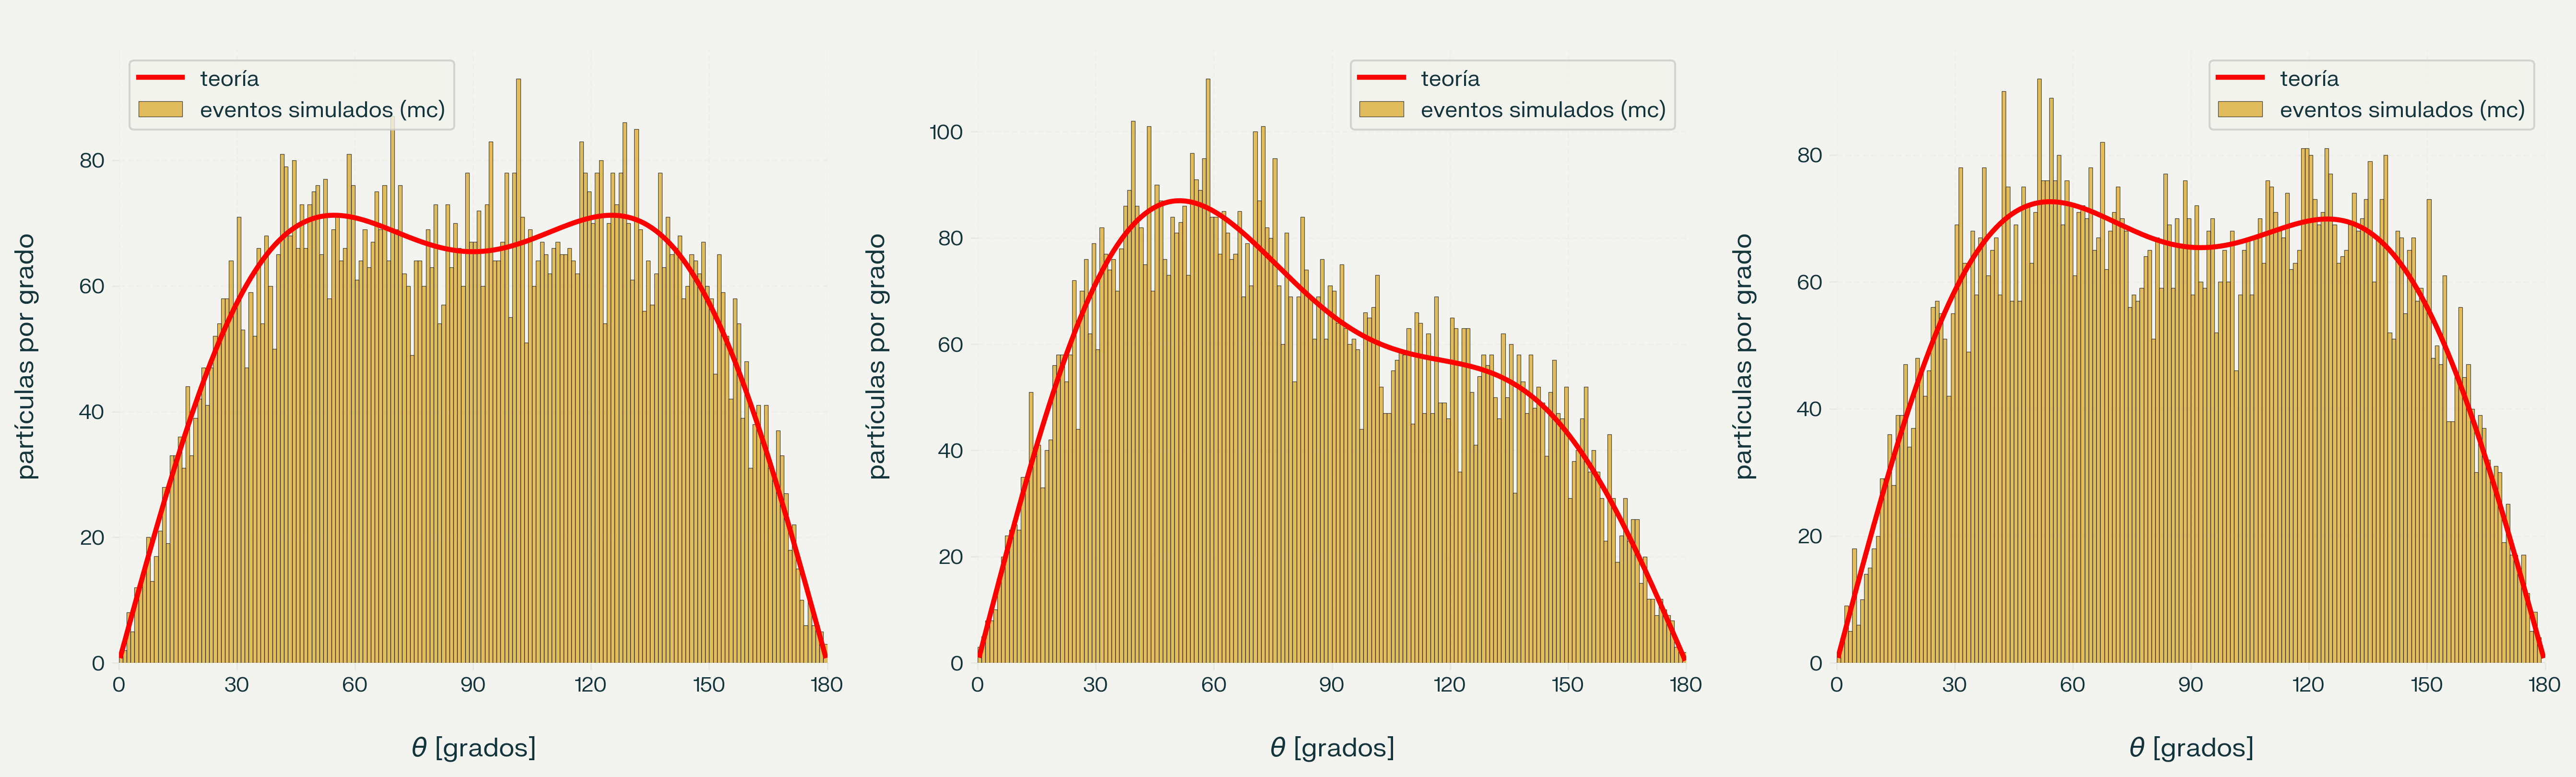

/usr/local/lib/python3.12/site-packages/pydantic/main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(PydanticSerializationUnexpectedValue: Expected `str` - serialized value may not be as expected [input_value=0, input_type=int64]
PydanticSerializationUnexpectedValue: Expected `float` - serialized value may not be as expected [input_value=0, input_type=int64])
  PydanticSerializationUnexpectedValue(Expected `ScatterChart` - serialized value may not be as expected [input_value=LineChart(type=<ChartType...120'], y_scale='linear'), input_type=LineChart])
  PydanticSerializationUnexpectedValue(Expected `BarChart` - serialized value may not be as expected [input_value=LineChart(type=<ChartType...120'], y_scale='linear'), input_type=LineChart])
  PydanticSerializationUnexpectedValue(Expected `PieChart` - serialized value may not be as expected [input_value=LineChart(type=<ChartType...120'], y_scale='linear'), input_type=LineChart])
  PydanticSerializ

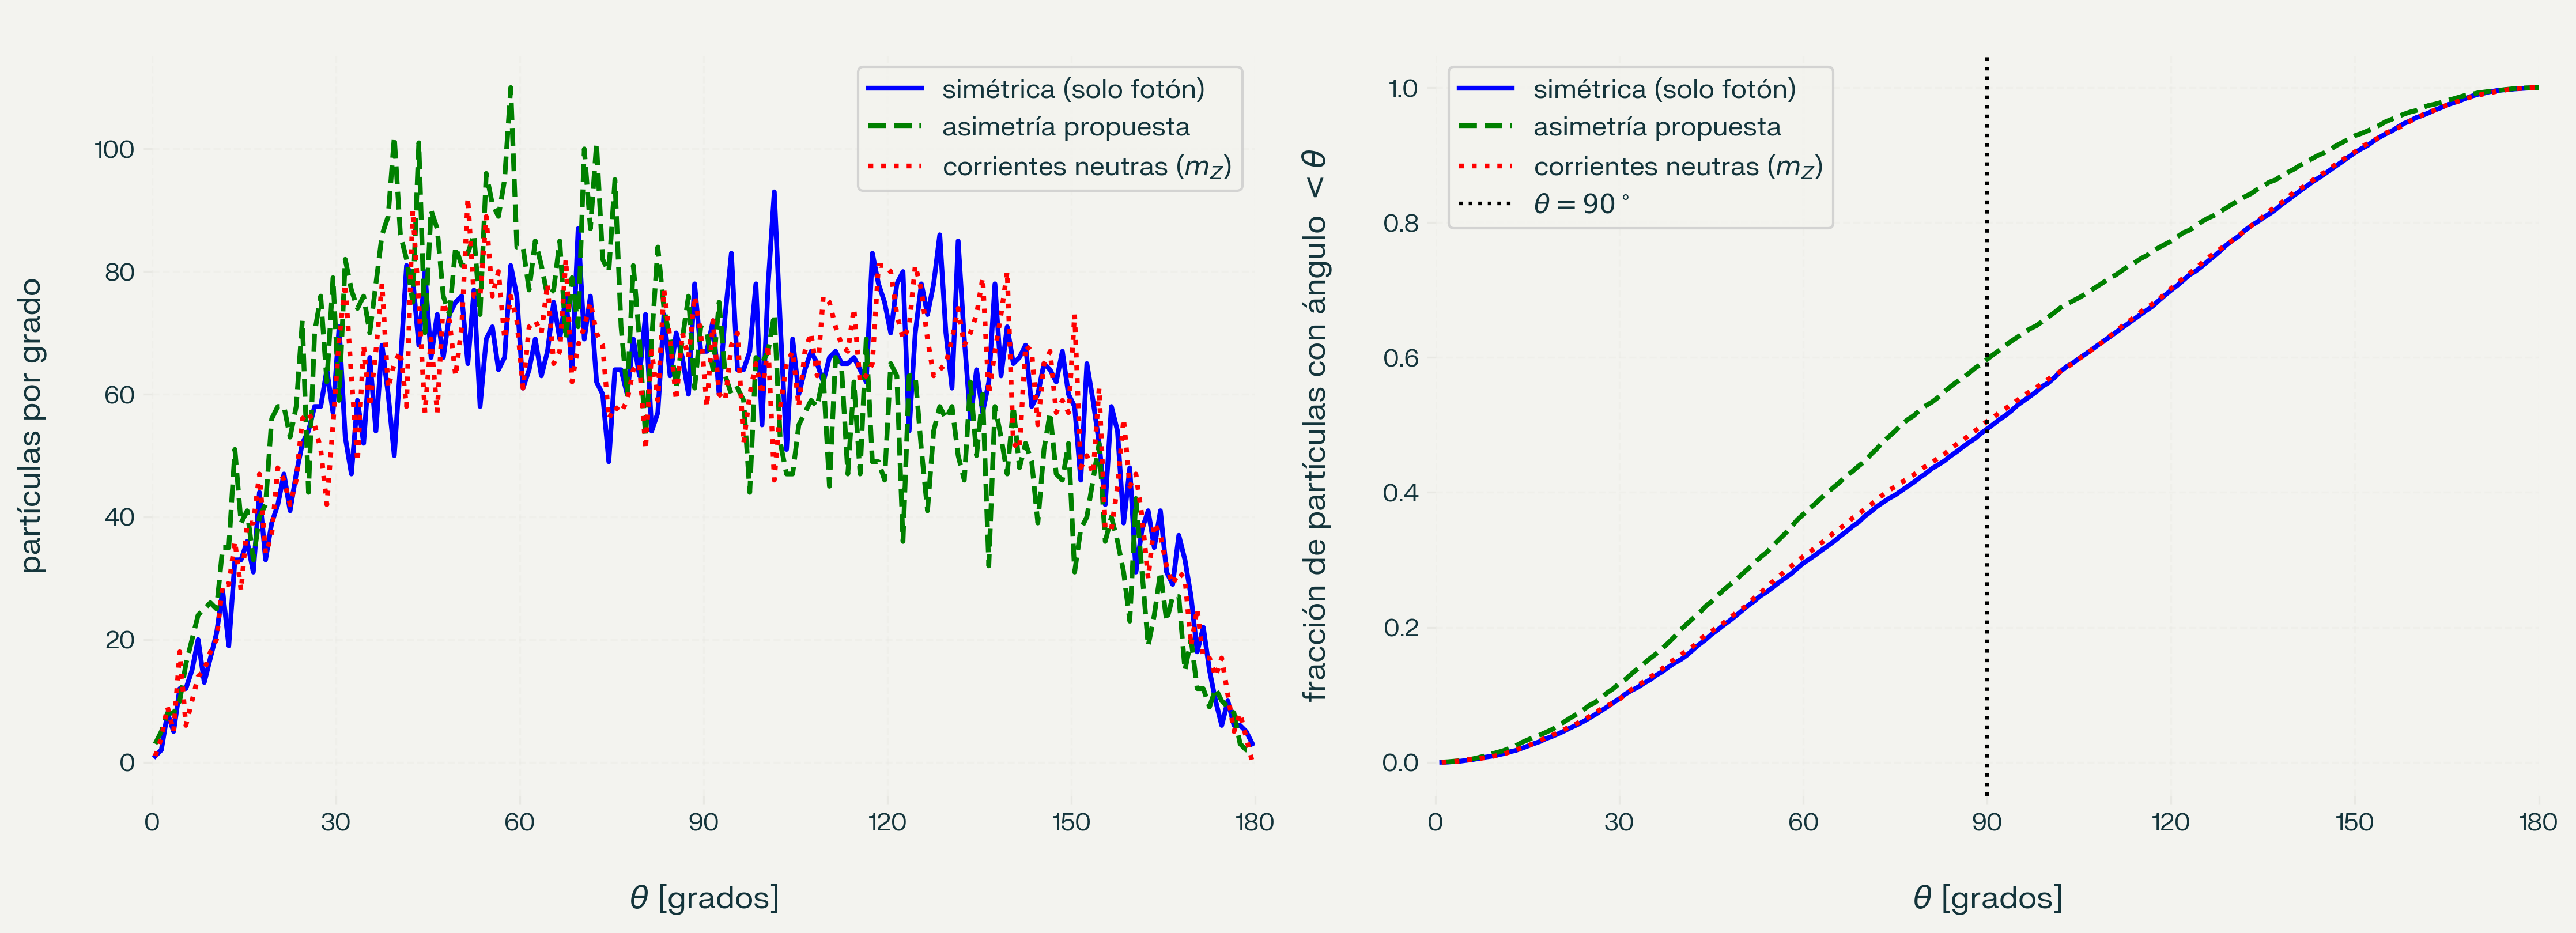

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (nombre, ev, A_, B_), cuentas in zip(axes, casos, columnas):
    ax.bar(grados, cuentas, width=1.0, alpha=0.7, color='goldenrod',
           edgecolor='black', linewidth=0.3, label='eventos simulados (mc)')
    ax.plot(grados, esperado_por_grado(A_, B_, len(ev)), 'r-', linewidth=2.5, label='teoría')
    ax.set_xlabel(r'$\theta$ [grados]', fontsize=13)
    ax.set_ylabel('partículas por grado', fontsize=13)
    ax.set_title(nombre, fontsize=13)
    ax.set_xlim(0, 180)
    ax.set_xticks(range(0, 181, 30))
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# comparación directa de los tres casos + fracción acumulada
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
estilos_c = ['b-', 'g--', 'r:']
nombres_c = ['simétrica (solo fotón)', 'asimetría propuesta', r'corrientes neutras ($m_Z$)']

ax = axes[0]
for cuentas, est, nom in zip(columnas, estilos_c, nombres_c):
    ax.plot(grados, cuentas, est, linewidth=2, label=nom)
ax.set_xlabel(r'$\theta$ [grados]', fontsize=13)
ax.set_ylabel('partículas por grado', fontsize=13)
ax.set_title('Comparación del conteo angular', fontsize=13)
ax.set_xlim(0, 180)
ax.set_xticks(range(0, 181, 30))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

ax = axes[1]
for cuentas, est, nom in zip(columnas, estilos_c, nombres_c):
    ax.plot(np.arange(1, 181), np.cumsum(cuentas) / cuentas.sum(), est, linewidth=2, label=nom)
ax.axvline(90, color='black', linestyle=':', linewidth=1.5, label=r'$\theta=90^\circ$')
ax.set_xlabel(r'$\theta$ [grados]', fontsize=13)
ax.set_ylabel(r'fracción de partículas con ángulo $<\theta$', fontsize=13)
ax.set_title('Conteo acumulado', fontsize=13)
ax.set_xlim(0, 180)
ax.set_xticks(range(0, 181, 30))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

### ***lista completa: los 180 intervalos (corrientes neutras en $\sqrt{s}=m_Z$)***

Resultado para **cada** grado, en tres columnas.

In [14]:
cuentas_nc = columnas[2]
print("grado        partículas    |  grado        partículas    |  grado        partículas")
for k in range(60):
    linea = ""
    for j in (k, k + 60, k + 120):
        linea += f"{j:3d}° - {j+1:3d}°   {cuentas_nc[j]:5d}        |  "
    print(linea.rstrip(" |"))

grado        partículas    |  grado        partículas    |  grado        partículas
  0° -   1°       1        |   60° -  61°      61        |  120° - 121°      80
  1° -   2°       4        |   61° -  62°      71        |  121° - 122°      73
  2° -   3°       9        |   62° -  63°      72        |  122° - 123°      69
  3° -   4°       5        |   63° -  64°      70        |  123° - 124°      71
  4° -   5°      18        |   64° -  65°      78        |  124° - 125°      81
  5° -   6°       6        |   65° -  66°      65        |  125° - 126°      77
  6° -   7°      10        |   66° -  67°      67        |  126° - 127°      69
  7° -   8°      14        |   67° -  68°      82        |  127° - 128°      63
  8° -   9°      15        |   68° -  69°      62        |  128° - 129°      64
  9° -  10°      18        |   69° -  70°      68        |  129° - 130°      65
 10° -  11°      20        |   70° -  71°      71        |  130° - 131°      69
 11° -  12°      29        |   71° -

### ***dependencia del conteo con la energía***

Como $A_{FB}$ depende de $\sqrt{s}$, el reparto por grado también. El conteo se repite a tres energías: debajo del polo (los muones tienden a salir hacia atrás), en el polo (casi simétrico) y arriba (hacia adelante). El $\theta$ pequeño corresponde a *forward* y el cercano a $180^\circ$ a *backward*.

raiz_s =  80.0000 GeV:  forward (0°-90°) = 1361   backward (90°-180°) = 8639
raiz_s =  91.1876 GeV:  forward (0°-90°) = 5012   backward (90°-180°) = 4988
raiz_s = 105.0000 GeV:  forward (0°-90°) = 8511   backward (90°-180°) = 1489


/usr/local/lib/python3.12/site-packages/pydantic/main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(PydanticSerializationUnexpectedValue: Expected `str` - serialized value may not be as expected [input_value=0, input_type=int64]
PydanticSerializationUnexpectedValue: Expected `float` - serialized value may not be as expected [input_value=0, input_type=int64])
  PydanticSerializationUnexpectedValue(Expected `ScatterChart` - serialized value may not be as expected [input_value=LineChart(type=<ChartType...180'], y_scale='linear'), input_type=LineChart])
  PydanticSerializationUnexpectedValue(Expected `BarChart` - serialized value may not be as expected [input_value=LineChart(type=<ChartType...180'], y_scale='linear'), input_type=LineChart])
  PydanticSerializationUnexpectedValue(Expected `PieChart` - serialized value may not be as expected [input_value=LineChart(type=<ChartType...180'], y_scale='linear'), input_type=LineChart])
  PydanticSerializ

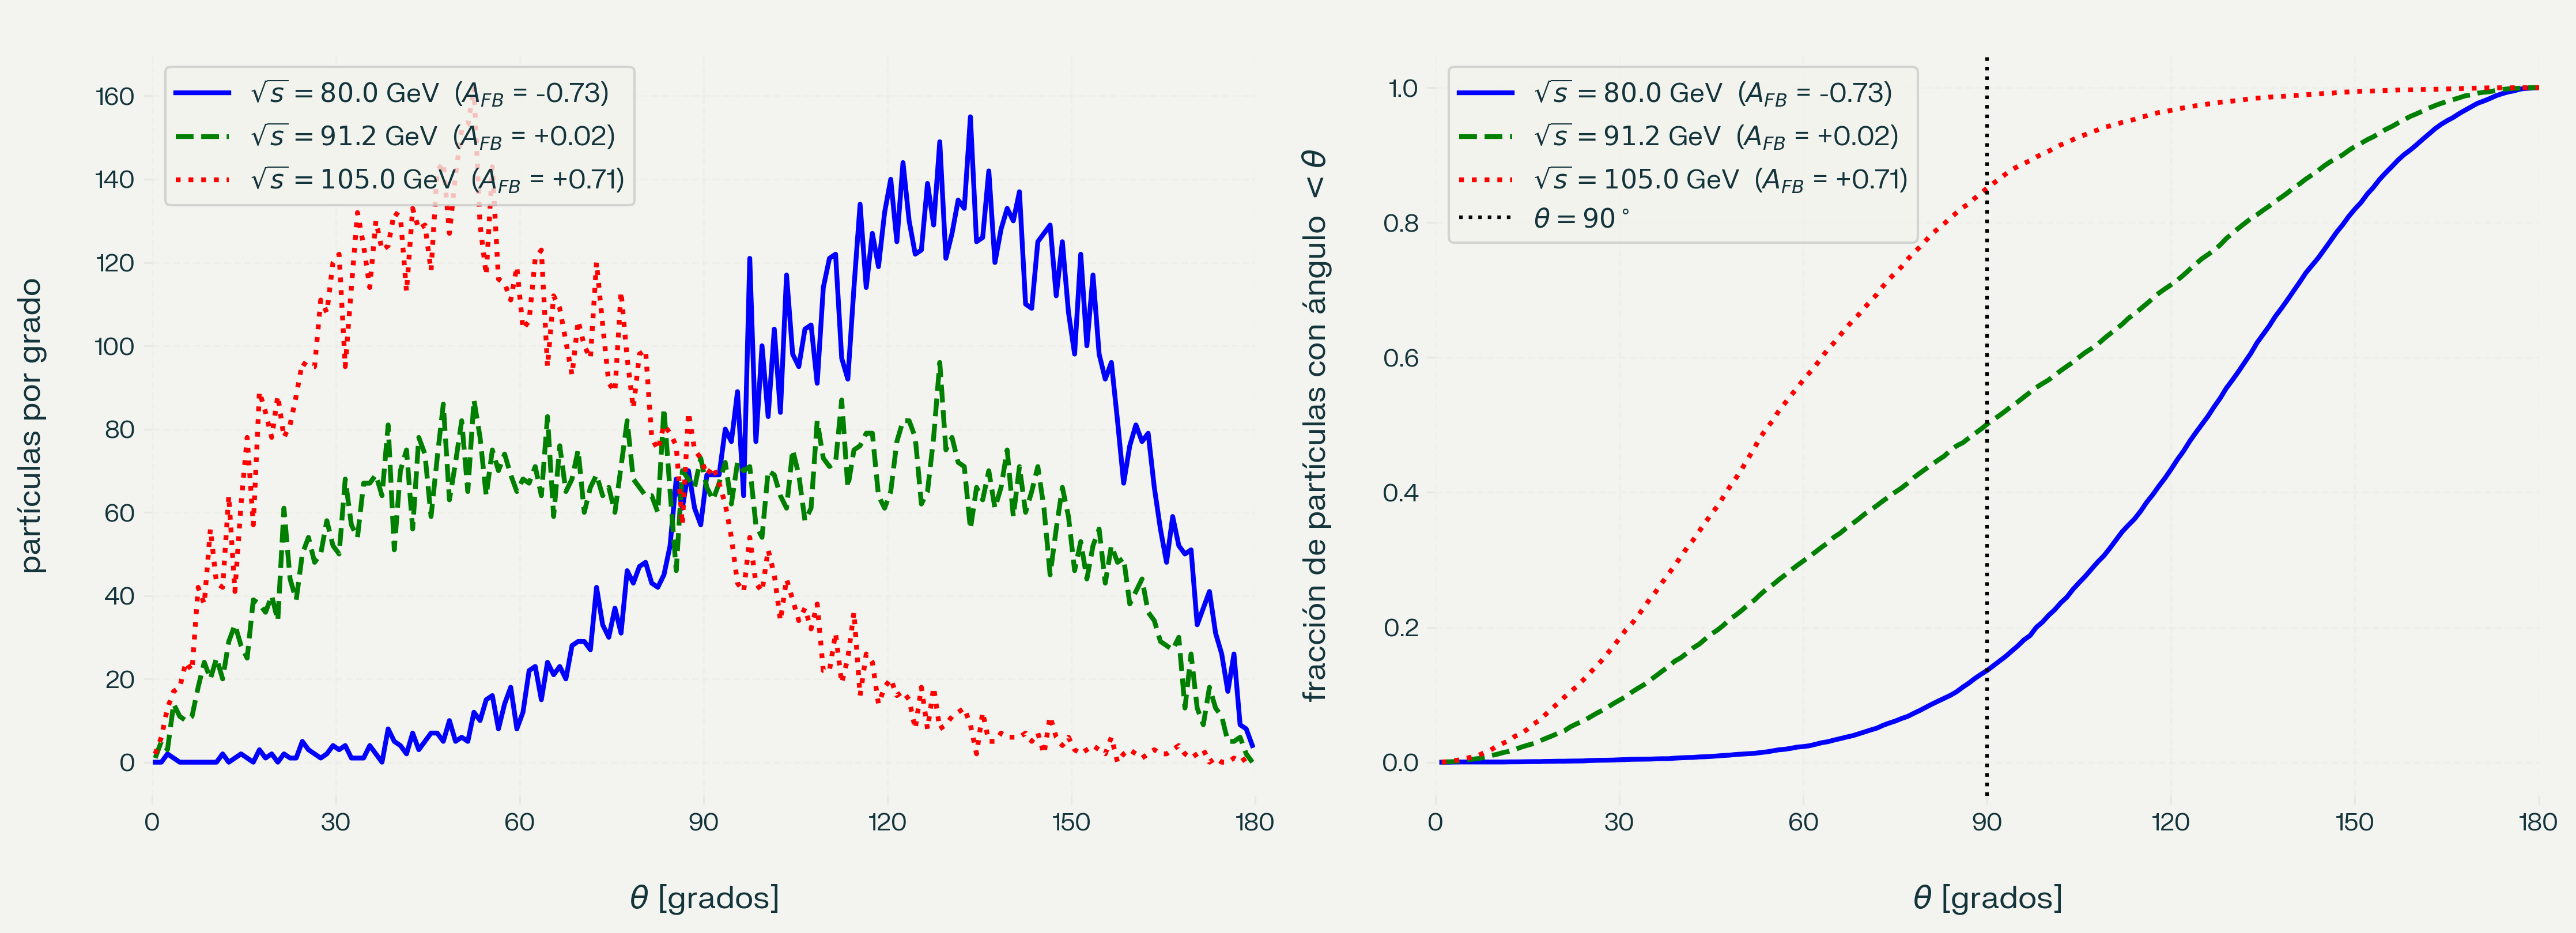


guardado: conteo_angular.csv  (180 filas)


In [15]:
energias_conteo = [(80, 'b-'), (m_Z, 'g--'), (105, 'r:')]
conteos_E = []

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for E, est in energias_conteo:
    A_E_, B_E_ = coeficientes(E)
    ev, _ = rejection_sampling(A_E_, B_E_, n_events)
    cuentas, _ = particulas_por_grado(ev)
    conteos_E.append(cuentas)
    etiqueta = rf'$\sqrt{{s}}={E:.1f}$ GeV  ($A_{{FB}}$ = {3*B_E_/(8*A_E_):+.2f})'
    axes[0].plot(grados, cuentas, est, linewidth=2, label=etiqueta)
    axes[1].plot(np.arange(1, 181), np.cumsum(cuentas) / cuentas.sum(), est, linewidth=2, label=etiqueta)
    print(f"raiz_s = {E:8.4f} GeV:  forward (0°-90°) = {np.sum(cuentas[:90])}   backward (90°-180°) = {np.sum(cuentas[90:])}")

axes[1].axvline(90, color='black', linestyle=':', linewidth=1.5, label=r'$\theta=90^\circ$')
titulos = ['Conteo por grado a distintas energías', 'Conteo acumulado a distintas energías']
ylabels = ['partículas por grado', r'fracción de partículas con ángulo $<\theta$']
for ax, tit, yl in zip(axes, titulos, ylabels):
    ax.set_xlabel(r'$\theta$ [grados]', fontsize=13)
    ax.set_ylabel(yl, fontsize=13)
    ax.set_title(tit, fontsize=13)
    ax.set_xlim(0, 180)
    ax.set_xticks(range(0, 181, 30))
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# archivo con las 180 filas: grado_inicio, grado_fin, simétrica, asimetría propuesta, corrientes neutras
datos = np.column_stack([np.arange(0, 180), np.arange(1, 181)] + columnas)
np.savetxt("conteo_angular.csv", datos, delimiter=",", fmt="%d",
           header="grado_inicio,grado_fin,simetrica,asimetria_propuesta,corrientes_neutras", comments="")
print("\nguardado: conteo_angular.csv  (180 filas)")

## ***Conclusiones***

- el método de aceptación-rechazo reproduce las distribuciones teóricas en los tres casos ($\chi^2/\text{ndof}\approx1$ y residuos dentro de $\pm2\sigma$)
- la distribución es simétrica con solo el fotón, y al subir la energía hacia la resonancia la interferencia $\gamma$–$Z$ la inclina primero hacia *backward* y luego hacia *forward*
- en el polo de la $Z$ la interferencia se anula y $A_{FB}\approx0.017$ queda determinada por el término $ZZ$
- el error de $A_{FB}$ decrece como $1/\sqrt{N}$, y con $N=10^5$ se recupera $\sin^2\theta_W$ con un error de unos $0.002$, porque cerca del polo la Forward-Backward asymmetry es muy sensible a ese parámetro
- el conteo por grado reparte las 10 000 partículas en 180 intervalos y sigue la predicción teórica; su forma difiere de la de $x$ por el factor $\sin\theta$ del cambio de variable

**Limitaciones:** el cálculo es a nivel árbol, sin correcciones radiativas, sin radiación de estado inicial, sin efectos del detector, y considera solo la forma angular (no la sección eficaz absoluta).